# 📦 Eniac Rabattstrategie — Gesamtnotebook (durchgehender Lauf, konsistente Namenskonvention)

**Ein Durchlauf, drei Phasen, klare Namensgrenzen:**
- Teil A (Bereinigung): `orders_cl`, `orderlines_cl`, `products_cl`, `brands_cl`
- Teil B (Qualität): `orders_qu`, `orderlines_qu`, `products_qu`, `brands_qu`
- Teil C (Analyse + Kategorien): `orders_analyse`, `orderlines_analyse`, `products_analyse`, `brands_analyse`, gemergt: `orderlines_products_analyse`

Originaldaten werden nur EINMAL in Teil A geladen. Jede Phase erstellt am Anfang eine **eigene `.copy()`** von den Ergebnissen der Vorphase (🔗 Brücken-Zellen) — nie werden Originale oder Vorphasen-Daten direkt weiterbearbeitet.

Teil D (Visualisierung/Speichern als Bilddatei) folgt **erst, wenn final entschieden ist**, was analysiert und präsentiert wird — bewusst noch nicht Teil dieses Notebooks.

⚠️ Export-Zeilen (`.to_csv`, `files.download`) sind auskommentiert — bei Bedarf gezielt aktivieren.

---
# TEIL A — Bereinigung (Meilenstein 1–3) → Ergebnis: *_cl

# 01 – Eniac Rabattstrategie: Datenbereinigung
**Meilenstein 1–3** (siehe Projektplan)

Ziel: Rohdaten einlesen, explorieren und grundlegend bereinigen (Duplikate, Datentypen, fehlende Werte).

**Inhaltsverzeichnis**
1. Daten einlesen (Original)
2. Copy erstellen
3. Exploration der Daten
4. Duplikate
5. Datentypen prüfen
6. Fehlende Werte prüfen
7. Speichern

In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 1. Daten einlesen (Original) — Meilenstein 1

### 1.1 orderlines.csv

In [ ]:
url = "https://drive.google.com/file/d/11bPnYi-rm-7u0fY0bPQiQMANi42Heinw/view?usp=sharing" # orderlines.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orderlines = pd.read_csv(path)

### 1.2 orders.csv

In [ ]:
url = "https://drive.google.com/file/d/1lnjRkOcjvKRnXTDy4EJs3RkLhbnT6riZ/view?usp=sharing" # orders.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orders = pd.read_csv(path)

### 1.3 brands.csv

In [ ]:
url = "https://drive.google.com/file/d/17nX88jyuIBHuv4yp8bVJIdcmLiZaO6vr/view?usp=sharing" # brands.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_brands = pd.read_csv(path)

### 1.4 products.csv

In [ ]:
url = "https://drive.google.com/file/d/1pWbwYB39QWeMD7yEpe6QiDW5Cr3n_Cdb/view?usp=sharing" # products.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_products = pd.read_csv(path)

## 2. Copy erstellen

In [ ]:
orderlines_cl = df_orderlines.copy()
orders_cl = df_orders.copy()
brands_cl = df_brands.copy()
products_cl = df_products.copy()

## 3. Exploration der Daten

In [ ]:
orderlines_cl.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38


In [ ]:
orders_cl.head(5)

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [ ]:
brands_cl.head(5)

,short,long
0,8MO,8Mobility
1,ACM,Acme
2,ADN,Adonit
3,AII,Aiino
4,AKI,Akitio


In [ ]:
products_cl.head(5)

,sku,name,desc,price,promo_price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59,589.996,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59,569.898,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25,229.997,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364


**Ergebnis:**
- `desc` hat 7 fehlende Werte
- `price` hat 46 fehlende Werte
- `type` ist ein String (Kategorie-/Produkttyp-Code, keine Rechenoperation nötig), 50 fehlende Werte
- `in_stock` ist der Lagerstatus

### 3.1 `.info()`, `.unique()`

In [ ]:
orderlines_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
memory usage: 15.7+ MB


In [ ]:
orders_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [ ]:
brands_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [ ]:
products_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [ ]:
products_cl['sku'].unique()

array(['RAI0007', 'APP0023', 'APP0025', ..., 'THU0061', 'THU0062',
       'THU0063'], dtype=object)

### 3.2 Ungewöhnliche Werte prüfen
Beispiel: `APP2302` hat `type` = `1,02E+12` — das ist wissenschaftliche Notation (1,02 × 10¹²), typisch wenn Excel eine lange Zahl automatisch formatiert hat. **Fazit:** separat betrachten, nicht direkt korrigierbar in dieser Phase.

### 3.3 Preis-Spalte (`products`) explorativ prüfen

In [ ]:
products_cl['price'].str.count(r"\.").value_counts()

,count
price,
0.00,11528
1.00,7321
2.00,431


In [ ]:
mult_decimal_rows = (products_cl['price'].str.count(r"\.") > 1).sum()
percent_corrupted = (100 * mult_decimal_rows / products_cl.shape[0])
print(f"{percent_corrupted:.2f}% der Zeilen haben mehrere Dezimalstellen im price")

2.23% der Zeilen haben mehrere Dezimalstellen im price


**Ergebnis:**
- 0 Punkte: wahrscheinlich Ganzzahl-Preise ohne Dezimalstelle (z. B. "59")
- 1 Punkt: normale Preise (z. B. "59.99")
- 2 Punkte: korrupte Preise (z. B. "26.155.941")

In [ ]:
mask_corrupted = products_cl['price'].str.count(r"\.") > 1
products_cl.loc[mask_corrupted, 'price']

,price
665,1.639.792
792,4.694.994
797,4.090.042
827,2.199.791
885,5.609.698
898,69.989.909
941,69.989.909
943,2.099.895
1057,1.329.911
1058,1.599.862


**Ergebnis:**
- Der letzte Punkt ist vermutlich das Dezimalzeichen, die anderen sind Tausendertrennzeichen (z. B. "1.639.792" → 1639,79 €).
- **Entscheidung:** Korrektur erfolgt NICHT hier, sondern in Meilenstein 4 (Qualität) — siehe Projektplan "Nachträglich bereinigt".

## 4. Duplikate

### 4.1 Duplikate anschauen

In [ ]:
mask_duplicated = products_cl.duplicated()
products_cl.loc[mask_duplicated]

,sku,name,desc,price,promo_price,in_stock,type
101,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
102,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
103,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
104,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
105,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
...,...,...,...,...,...,...,...
16831,APP2302,"Apple MacBook Pro 13 ""Core i5 Touch Bar 33GHz ...",New MacBook Pro 13-inch Core i5 Touch Bar 33 G...,26.155.941,26.155.941,0,"1,02E+12"
16833,APP2303,"Apple MacBook Pro 13 ""Core i5 Touch Bar 33GHz ...",New MacBook Pro 13 inch Touch Bar 33 GHz Core ...,237.559.421,23.755.942,0,"1,02E+12"
18190,PAR0077,Parrot Bebop Drone 2 Power,Drone cuadricóptero quality camera integrated ...,699.9,6.733.892,0,11905404
18308,NKI0010,Nokia Wireless sphygmomanometer Plata,Sphygmomanometer for iPhone iPad and iPod App.,129.99,1.149.899,1,11905404


### 4.2 Duplikate prüfen

In [ ]:
orderlines_cl.duplicated().sum()

np.int64(0)

In [ ]:
orders_cl.duplicated().sum()

np.int64(0)

In [ ]:
products_cl.duplicated().sum()

np.int64(8746)

In [ ]:
num_duplicated = products_cl.duplicated().sum()
total_rows = products_cl.shape[0]
percent_duplicated = (100 * num_duplicated / total_rows)
print(f"{percent_duplicated:.2f}% der Zeilen sind Duplikate")

45.26% der Zeilen sind Duplikate


In [ ]:
products_cl.duplicated().value_counts(normalize=True)

,proportion
False,0.55
True,0.45


**Ergebnis:** In `orders` und `orderlines` gibt es keine Duplikate. In `products` sind über 45 % der Zeilen Duplikate.

### 4.3 Duplikate entfernen

In [ ]:
products_cl = products_cl.drop_duplicates()
products_cl.shape

(10580, 7)

**Ergebnis:** Nach Entfernung 10.580 Zeilen in `products`, davon 377 (3,56 %) mit korrupten Mehrfach-Punkt-Preisen (Korrektur folgt in Meilenstein 4).

## 5. Datentypen prüfen

### 5.1 Bestellungen — `created_date`

In [ ]:
orders_cl["created_date"] = pd.to_datetime(orders_cl["created_date"])

**Ergebnis:** Datentyp jetzt Datum/Uhrzeit — nach dem Import kontrollieren.

### 5.2 Auftragszeilen — `date`

In [ ]:
orderlines_cl["date"] = pd.to_datetime(orderlines_cl["date"])

### 5.3 Auftragszeilen — `unit_price` (float)


Im Datensatz wurden fehlerhafte Preisformate gefunden (z. B. `34.56.546`), die nicht direkt in numerische Werte umgewandelt werden konnten.

Anstatt diese Datensätze zu löschen, entschied sich unser Team für eine Korrektur der Preisangaben. Der Grund dafür war, dass diese Produkte mit **36169 Bestellpositionen** verknüpft sind, darunter **3561 abgeschlossene Bestellungen (Completed)**.

Daher wurde die erste fehlerhafte Trennstelle entfernt, die Preise auf zwei Dezimalstellen gerundet und anschließend in numerische Werte umgewandelt.

### 1- Fehlerhafte unit_Preise identifizieren

Betroffene Bestellungen analysieren.
Zunächst werden alle Produkte identifiziert, deren Preis mehr als einen Punkt enthält.

In [ ]:
unit_price_mask = orderlines_cl['unit_price'].str.count(r'\.') > 1
umsätze_zwei_punkte = orderlines_cl.loc[unit_price_mask,:]
orderlines_cl.loc[unit_price_mask, 'unit_price'].shape[0]

36169

### 2-⁠ ⁠Auswirkungen auf abgeschlossene Bestellungen

Zur Entscheidungsfindung wird untersucht, wie viele der betroffenen Bestellungen bereits abgeschlossen wurden.

In [ ]:
orders_umsätse_merged = orders_cl.merge(umsätze_zwei_punkte,left_on='order_id', right_on='id_order',how='inner')
orders_umsätse_merged
orders_umsätse_merged['state'].value_counts()

,count
state,
Shopping Basket,24425
Place Order,5245
Completed,3561
Cancelled,1802
Pending,1105


### 3- Preisformat korrigieren

Die erste fehlerhafte Trennstelle wird entfernt, sodass die Preise anschließend als numerische Werte gespeichert werden können.

In [ ]:
orderlines_cl.loc[unit_price_mask, 'unit_price'] = orderlines_cl.loc[unit_price_mask, 'unit_price'].str.replace('.','',1)


### 4- Datentyp umwandeln

Nach der Korrektur wird die Spalte in einen numerischen Datentyp umgewandelt.

In [ ]:
orderlines_cl['unit_price'] = pd.to_numeric(orderlines_cl['unit_price'])

### 5- Preise an Euro-Format anpassen

Zum Schluss werden die betroffenen Preise auf zwei Dezimalstellen angepasst.

In [ ]:
unit_price_mask = orderlines_cl.unit_price.astype(str).str.contains(r"\d+\.\d{3}")
orderlines_cl.loc[unit_price_mask ,'unit_price'] =round(orderlines_cl.loc[unit_price_mask , 'unit_price'], 2)

In [ ]:
orderlines_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                293983 non-null  int64         
 1   id_order          293983 non-null  int64         
 2   product_id        293983 non-null  int64         
 3   product_quantity  293983 non-null  int64         
 4   sku               293983 non-null  object        
 5   unit_price        293983 non-null  float64       
 6   date              293983 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 15.7+ MB


## 6. Fehlende Werte prüfen

### 6.1 Bestellungen (`orders`) — identifizieren

In [ ]:
orders_cl.isna().sum()

,0
order_id,0
created_date,0
total_paid,5
state,0


**Ergebnis:** `total_paid` hat 5 fehlende Werte — Entscheidung/Behandlung erfolgt in Meilenstein 4, falls relevant für die Umsatzanalyse.

In [ ]:
orders_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226909 non-null  int64         
 1   created_date  226909 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.9+ MB


In [ ]:
orders_cl = orders_cl.dropna(subset='total_paid')
orders_cl.shape[0]

226904

### 6.2 Produkte (`products`) — `price` / `desc`

In [ ]:
print("Beispiel-Zeilen mit fehlendem Preis:")
products_cl[products_cl['price'].isna()].head(5)

Beispiel-Zeilen mit fehlendem Preis:


,sku,name,desc,price,promo_price,in_stock,type
34,TWS0019,Twelve South MagicWand support Apple Magic Tra...,MagicWand for wireless keyboard and Magic Trac...,NaN,299.899,0,8696
1900,AII0008,Aiino Case MacBook Air 11 '' Transparent,MacBook Air 11-inch casing with matte finish.,NaN,22.99,0,13835403
2039,CEL0020,Celly Ambo Luxury Leather Case + iPhone 6 Case...,Cover and housing together with magnet for iPh...,NaN,399.905,0,11865403
2042,CEL0007,Celly Wallet Case with removable cover Black i...,Case Book for iPhone 6 card case type.,NaN,128.998,0,11865403
2043,CEL0012,Celly Silicone Hard Shell iPhone 6 Blue,Hard Shell Silicone iPhone 6.,NaN,4.99,0,11865403


In [ ]:
products_cl.isna().sum()

,0
sku,0
name,0
desc,7
price,46
promo_price,0
in_stock,0
type,50


**Ergebnis:** Weniger als 0,5 % der Zeilen betroffen → löschen.

In [ ]:
percent_corrupted = (100 * (products_cl["price"].isna().sum()) / products_cl.shape[0])
print(f"{percent_corrupted:.2f}% der Zeilen haben einen fehlenden price")

0.43% der Zeilen haben einen fehlenden price


In [ ]:
products_cl = products_cl.dropna(subset='price')
products_cl.shape[0]

10534

In [ ]:
products_cl.loc[products_cl['desc'].isna(), :]

,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


In [ ]:
products_cl.loc[products_cl['desc'].isna(), 'desc'] = products_cl.loc[products_cl['desc'].isna(), 'name']
products_cl['desc'].isna().sum()

np.int64(0)

**Ergebnis:** `desc` wird bewusst nicht vollständig entfernt/ignoriert — wird später zur Kategorisierung genutzt (siehe Analyse-Notebook).

### 6.3 Bestellpositionen (`orderlines`) — restliche fehlende Werte

In [ ]:
orderlines_cl = orderlines_cl.dropna(axis=0)

## 7. Speichern (Meilenstein 3 Abschluss)
Export als `orders_cl.csv`, `orderlines_cl.csv`, `products_cl.csv` → Ordner `2.Data/1.Data_cleaned_01/final_CSV_cleaned/`.

In [ ]:
#Bereinigte Daten speichern in Drive

from google.colab import files

# orders_cl.to_csv("orders_cl.csv", index=False)
# files.download("orders_cl.csv")

# orderlines_cl.to_csv("orderlines_cl.csv", index=False)
# files.download("orderlines_cl.csv")

# products_cl.to_csv("products_cl.csv", index=False)
# files.download("products_cl.csv")

---
# TEIL B — Qualität (Meilenstein 4) → Ergebnis: *_qu

# 02 – Eniac Rabattstrategie: Datenqualität
**Meilenstein 4** (siehe Projektplan)

**Team-Entscheidung:** Status-Filter = nur `Completed` (einheitlich für die gesamte Qualitäts- und Analysephase).

**Inhaltsverzeichnis**
1. Import der bereinigten Datensätze (Meilenstein 1–3)
2. Arbeitskopien erstellen
3. Bereinigung der Zeichenketten (String-Spalten)
4. Fehlerhafte Preisangaben (products) korrigieren
5. Spalte `type` – fehlende Werte
6. Unerwünschte Bestellungen ausschließen
7. IDs zwischen orders und orderlines abgleichen
8. Bestellungen mit unbekannten Produkten ausschließen
9. Umsatz-Konsistenz prüfen (total_paid vs. unit_price_total)
10. Ausreißer entfernen (IQR-Regel)
11. Speichern

In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 1. Import der bereinigten Datensätze aus Meilenstein 1–3

### 🔗 Brücke aus Teil A — eigene Arbeitskopie erstellen (kein Reimport von Drive)

In [ ]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()
brands_qu = brands_cl.copy()

## 2. Arbeitskopien erstellen

In [ ]:
orderlines_qu = orderlines_qu.drop(columns=['product_id'])

**Ergebnis:** `product_id` enthielt ausschließlich den Wert 0 → entfernt.

*Hinweis:* Spaltennamen (`order_id` / `id_order`) werden NICHT umbenannt, um Konsistenz mit den bereits abgestimmten Merge-Aufrufen (`left_on`/`right_on`) zu wahren.

Datum konvertieren

In [ ]:
orderlines_qu["unit_price"] = pd.to_numeric(orderlines_qu["unit_price"])

## 3. Bereinigung der Zeichenketten (String-Spalten)
Führende/nachgestellte Leerzeichen können bei Zusammenführung oder Vergleich zu Fehlern führen.

### 3.1 orders

In [ ]:
str_cols = [col for col in orders_qu.columns if orders_qu[col].dtype == 'object']
for col in str_cols:
    orders_qu[col] = orders_qu[col].str.strip()

### 3.2 orderlines

In [ ]:
str_cols = [col for col in orderlines_qu.columns if orderlines_qu[col].dtype == 'object']
for col in str_cols:
    orderlines_qu[col] = orderlines_qu[col].str.strip()

### 3.3 products

In [ ]:
str_cols = [col for col in products_qu.columns if products_qu[col].dtype == 'object']
for col in str_cols:
    products_qu[col] = products_qu[col].str.strip()

### 3.4 brands

In [ ]:
str_cols = [col for col in brands_qu.columns if brands_qu[col].dtype == 'object']
for col in str_cols:
    brands_qu[col] = brands_qu[col].str.strip()

## 4. Fehlerhafte Preisangaben (`products`) korrigieren
In Meilenstein 1–3 wurden Preise mit mehreren Dezimalpunkten (z. B. `34.56.546`) nur identifiziert, nicht korrigiert. Hier werden sie repariert statt gelöscht.

### 4.1 Fehlerhafte Preise identifizieren

In [ ]:
price_mask = products_qu['price'].str.count(r'\.') > 1
products_qu.loc[price_mask, 'price'].shape[0]

377

### 4.2 Betroffene Bestellungen analysieren

In [ ]:
sku_list = products_qu.loc[price_mask, 'sku']
orderlines_mask = orderlines_qu['sku'].isin(sku_list)
umsätze_zwei_punkte = orderlines_qu.loc[orderlines_mask, :]
umsätze_zwei_punkte.shape[0]

4150

### 4.3 Auswirkungen auf abgeschlossene Bestellungen

In [ ]:
orders_umsätze_merged = orders_qu.merge(
    umsätze_zwei_punkte, left_on="order_id", right_on="id_order", how="inner"
)
orders_umsätze_merged['state'].value_counts()

,count
state,
Shopping Basket,2246
Completed,799
Place Order,601
Pending,258
Cancelled,246


**Ergebnis:** 799 der betroffenen Bestellungen haben Status `Completed` → **Entscheidung:** Preise korrigieren statt Zeilen löschen (Datenverlust vermeiden).

### 4.4 Preisformat korrigieren

In [ ]:
products_qu.loc[price_mask, 'price'] = products_qu.loc[price_mask, 'price'].str.replace('.', '', 1)

**Ergebnis:** erste fehlerhafte Trennstelle (Tausenderpunkt) entfernt.

### 4.5 Datentyp umwandeln

In [ ]:
products_qu['price'] = pd.to_numeric(products_qu['price'])

### 4.6 Preise an Euro-Format anpassen

In [ ]:
price_mask = products_qu.price.astype(str).str.contains(r"\d+\.\d{3}")
products_qu.loc[price_mask, 'price'] = round(products_qu.loc[price_mask, 'price'], 2)

**Ergebnis:** `price` jetzt vollständig numerisch mit 2 Dezimalstellen.

## 5. Spalte `type` — fehlende Werte
50 fehlende Werte, überwiegend Apple-Produkte. Da keine zuverlässige Ableitung möglich ist, werden die Zeilen NICHT gelöscht, sondern mit `'unbekannt'` aufgefüllt.

### 5.1 Fehlende Werte identifizieren

In [ ]:
type_mask = products_qu['type'].isna()
type_nan = products_qu.loc[type_mask, :]
type_nan.shape[0]

50

### 5.2 Auswirkungen auf Bestellungen analysieren

In [ ]:
orderlines_type_merged = orderlines_qu.merge(type_nan, on='sku', how='inner')
orderlines_type_merged.shape[0]

184

In [ ]:
dd = orders_qu.merge(orderlines_type_merged, left_on="order_id", right_on="id_order", how="inner")
mask = dd['state'] == 'Completed'
dd.loc[mask, :].shape[0]

13

### 5.3 Auffüllen mit `'unbekannt'`

In [ ]:
products_qu.loc[type_mask, 'type'] = 'unbekannt'

**Ergebnis:** keine NaN-Werte mehr in `type`.

## 6. Unerwünschte Bestellungen ausschließen (nur `Completed`)

In [ ]:
orders_qu = orders_qu.copy()
orderlines_qu = orderlines_qu.copy()
products_qu = products_qu.copy()

In [ ]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [ ]:
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]
orders_qu.shape

(46605, 4)

## 7. IDs zwischen orders und orderlines abgleichen

In [ ]:
orders_qu.order_id.nunique()

46605

In [ ]:
orderlines_qu.id_order.nunique()

204855

In [ ]:
orders_orderlines = orders_qu.merge(
    orderlines_qu, how="inner", left_on="order_id", right_on="id_order"
)

In [ ]:
# .unique() liefert die tatsächlichen IDs (nicht .nunique(), das nur die Anzahl liefert)
order_ids = orders_orderlines["order_id"].unique()

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(order_ids), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(order_ids), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46560, 46560)

## 8. Bestellungen mit unbekannten Produkten ausschließen

In [ ]:
orderlines_products = orderlines_qu.merge(
    products_qu, how="left", on="sku"
)[["id_order", "sku", "name"]]
orderlines_products.sample(10)

,id_order,sku,name
13288,330164,KAN0013,IAdapt Kanex Mini DisplayPort to HDMI with Aud...
46570,470787,OWC0256,Mac OWC Memory 2GB DDR3 1333MHZ SO-DIMM
36290,431654,WHO0007,Whoosh GO Cleaner Spray 30ml
51420,487605,PAC2117,"Apple iMac 27 ""Core i7 Retina 5K 42GHz | 16GB ..."
31560,419855,SPE0190,"Speck Case SmartShell MacBook Pro 13 ""(Late 20..."
23297,390342,LAC0186,1TB LaCie Rugged USB 3.0 Thunderbolt
53758,496156,ZAG0032,Rugged Messenger Zagg iPad Keyboard Folio (201...
25447,398466,DEV0009,Devolo dLAN 500 Wi-Fi adapter PLC
10231,345040,WAC0239,"Cintiq Wacom Graphics Tablet Pro 16 ""UHD Adobe..."
33366,425732,TOS0018,Toshiba Canvio Basic Hard Disk 1TB USB 3.0 25 ...


In [ ]:
orderlines_products.name.isna().value_counts()

,count
name,
False,61710
True,393


In [ ]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, 300029, 300251, 300340, 300558, 301178,
       301232, 301386, 301419, 301527, 301752, 301764, 301832, 301854,
       302069, 302078, 302431, 302447, 302872, 302890, 303158, 303274,
       303568, 304155, 304307, 304358, 304577, 304922, 305281, 305417,
       305824, 306293, 306419, 306743, 306907, 307102, 307969, 308132,
       308724, 309065, 309082, 309602, 309917, 310765, 311249, 311739,
       311982, 312031, 312445, 312565, 268659, 313073, 313726, 314221,
       314494, 314704, 314765, 315035, 315107, 315613, 316890, 317008,
       317178, 317360, 317552, 317803, 318378, 318928, 318935, 319101,
       319230, 320001, 315949, 320993, 321175, 321181, 322505, 322824,
       322865, 323457, 323573, 323669, 323741, 324014, 324310, 324652,
       325033, 325487, 325548, 326045, 326243, 326799, 326957, 326906,
       327268, 331604, 335991, 339946, 340890, 340892, 341352, 347004,
       348338, 348684, 348874, 348891, 348998, 349041, 349136, 349139,
      

In [ ]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete), :]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46172, 46172)

## 9. Umsatz-Konsistenz prüfen (`total_paid` vs. `unit_price_total`)

In [ ]:
orderlines_qu_copy = orderlines_qu.copy()
orders_qu_copy = orders_qu.copy()

In [ ]:
orderlines_qu_copy["unit_price_total"] = (
    orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]
)

In [ ]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False: gruppierte Spalte bleibt als Spalte erhalten (nicht Index)

In [ ]:
diff_df = orders_qu_copy.merge(
    orderlines_order_ids, left_on="order_id", right_on="id_order"
)

In [ ]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246018,2017-02-13 23:02:57,211.95,Completed,246018,206.96,4.99
6,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
7,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
8,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
9,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99


In [ ]:
diff_df['difference'].round(2).value_counts()

,count
difference,
0.00,13818
4.99,11174
6.99,10801
3.99,6923
19.99,571
0.01,524
9.99,485
7.00,339
-0.01,252


In [ ]:
diff_df.difference.mean().round(2)

np.float64(4.25)

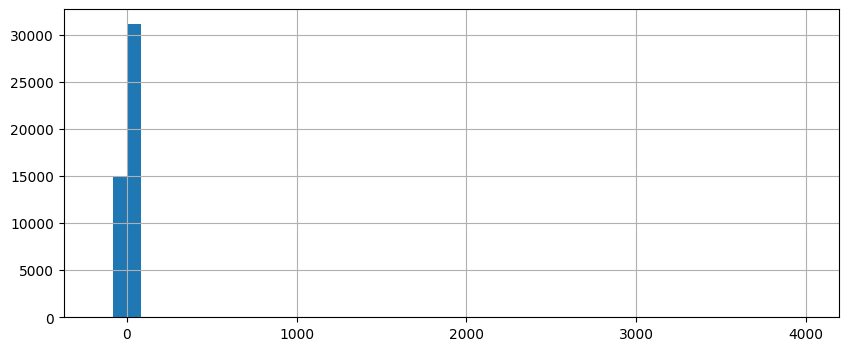

In [ ]:
diff_df.difference.hist(bins=50, figsize=(10, 4));

In [ ]:
diff_df.difference.describe()

,difference
count,46172.00
mean,4.25
std,24.83
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


**Interpretation:** Quartile passen zu plausiblen Versandkosten (0,00 / 4,99 / 6,99). Extremwerte (Min/Max) deuten auf fehlerhafte Daten hin → Ausreißerbehandlung folgt.

## 10. Ausreißer entfernen (IQR-Regel)

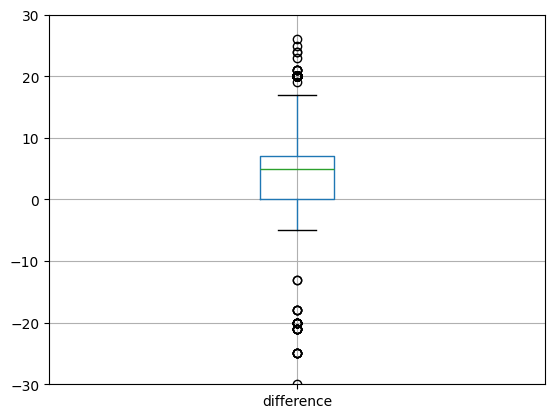

In [ ]:
import matplotlib.pyplot as plt
ax = diff_df.boxplot("difference")
ax.set_ylim(-30, 30)
plt.show()

In [ ]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(6.989999999999981)

In [ ]:
Q1 - 1.5 * IQR  # untere Grenze

np.float64(-10.484999999999971)

In [ ]:
Q3 + 1.5 * IQR  # obere Grenze

np.float64(17.47499999999995)

In [ ]:
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5 * IQR))
    & (diff_df["difference"] <= (Q3 + 1.5 * IQR)),
    :
]

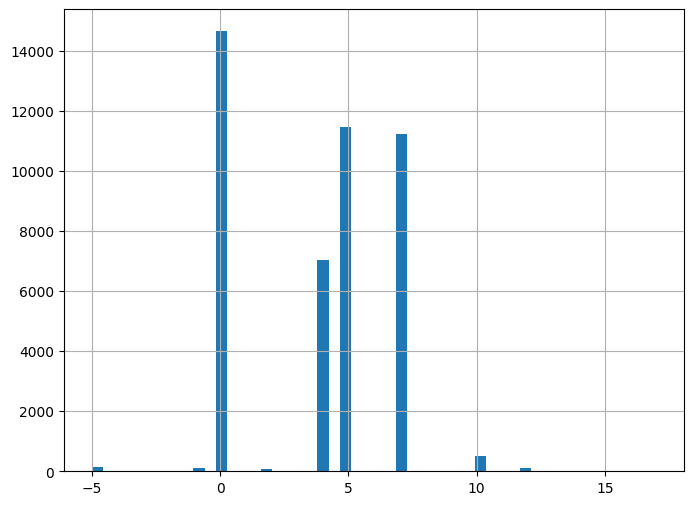

In [ ]:
diff_no_outliers_df.difference.hist(bins=50, figsize=(8, 6));

<Axes: >

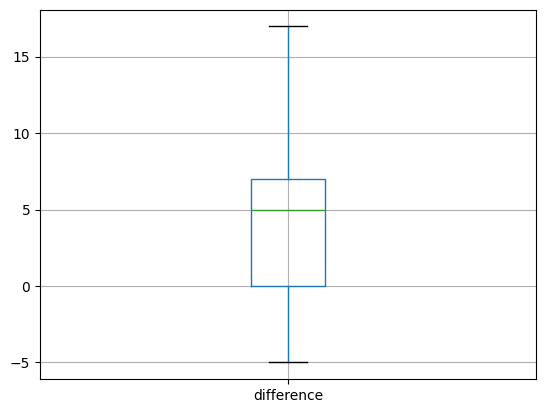

In [ ]:
diff_no_outliers_df.boxplot("difference")

In [ ]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(45418, 45418)

## 11. Speichern (Abschluss Meilenstein 4)

- Export als `orders_qu.csv`, `orderlines_qu.csv`, `products_qu.csv`,`brands_qu.csv` → Ordner `2.Data/2.Data_cleaned_01/final_CSV_quality/`.

In [ ]:
#Bereinigte Daten speichern in Drive

from google.colab import files

# orders_qu.to_csv("orders_qu.csv", index=False)
# files.download("orders_qu.csv")

# orderlines_qu.to_csv("orderlines_qu.csv", index=False)
# files.download("orderlines_qu.csv")

# products_qu.to_csv("products_qu.csv", index=False)
# files.download("products_qu.csv")

---
# TEIL C — Analyse & Kategorien (Meilenstein 5–6) → Ergebnis: *_analyse

# 03 – Eniac Rabattstrategie: Analyse
**Meilenstein 5–6** (siehe Projektplan)

**Projektziel:** Sind Rabatte für Eniac langfristig vorteilhaft (Position Marketing) oder schädlich für Umsatz und Positionierung (Position Vorstand/Investoren)?

**Entscheidende Frage:** Nimmt der Umsatz mit steigenden Rabatten zu?

**Inhaltsverzeichnis**
1. Import der qualitätsgeprüften Daten (Meilenstein 4)
2. Rabatt berechnen (`discount_percent`)
3. Bestellinformationen ergänzen
4. Kategorien erstellen
5. Zeitraum & Umsatz
6. Saisonale Muster
7. Meistverkaufte Produkte & Umsatz nach Kategorie
8. Rabattanalyse – Kernfrage
9. Zusatzanalysen (Preisempfehlung vs. Verkaufspreis, Bestellwert über Zeit, Produkt-Überschneidung)
10. Zusammenfassung / Entscheidungsgrundlage CEO

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

##1.Import der qualitätsgeprüften Daten (Meilenstein 4)

### 🔗 Brücke aus Teil B — eigene Arbeitskopie erstellen (kein Reimport von Drive)

In [ ]:
orders_analyse = orders_qu.copy()
orderlines_analyse = orderlines_qu.copy()
products_analyse = products_qu.copy()
brands_analyse = brands_qu.copy()

*Hinweis:* Die drei/vier Drive-Links müssen jeweils auf **unterschiedliche** Dateien zeigen (in einer früheren Version zeigten `orders_qu` und `orderlines_qu` versehentlich auf dieselbe Datei).

In [ ]:
orders_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45418 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45418 non-null  int64         
 1   created_date  45418 non-null  datetime64[ns]
 2   total_paid    45418 non-null  float64       
 3   state         45418 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [ ]:
orderlines_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60179 entries, 7 to 293661
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                60179 non-null  int64         
 1   id_order          60179 non-null  int64         
 2   product_quantity  60179 non-null  int64         
 3   sku               60179 non-null  object        
 4   unit_price        60179 non-null  float64       
 5   date              60179 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
products_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10534 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          10534 non-null  object 
 1   name         10534 non-null  object 
 2   desc         10534 non-null  object 
 3   price        10534 non-null  float64
 4   promo_price  10534 non-null  object 
 5   in_stock     10534 non-null  int64  
 6   type         10534 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 658.4+ KB


In [ ]:
brands_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


### 1.1 Arbeitskopien erstellen
🔗 **Wichtig:** Ab hier NUR noch mit den `_analyse`-Kopien weiterarbeiten — nicht mit `orders_qu`/`orderlines_qu`/`products_cl` direkt. So bleibt der Meilenstein-4-Datenstand unangetastet, falls ihr am Ende versehentlich mit demselben Dateinamen exportiert.

## 2. Rabatt berechnen (`discount_percent`)

In [ ]:
orderlines_products_analyse = orderlines_analyse.merge(products_analyse, on='sku', how='inner')

# --- RADIKALE BEREINIGUNG FÜR BEIDE SPALTEN ---
for col in ['unit_price', 'price']:
    orderlines_products_analyse[col] = orderlines_products_analyse[col].astype(str).str.strip()
    multi_point_mask = orderlines_products_analyse[col].str.count(r'\.') > 1
    orderlines_products_analyse.loc[multi_point_mask, col] = (
        orderlines_products_analyse.loc[multi_point_mask, col].str.replace('.', '', 1)
    )

    # 3 Nachkommastellen korrigieren (z.B. 5608.689 -> 560.87)
    temp_numeric = pd.to_numeric(orderlines_products_analyse[col], errors='coerce')
    three_decimals_mask = orderlines_products_analyse[col].str.contains(r'\.\d{3}$') & temp_numeric.notna()
    if three_decimals_mask.any():
        orderlines_products_analyse.loc[three_decimals_mask, col] = round(temp_numeric / 10, 2)

# Konvertierung in echte Zahlen
orderlines_products_analyse['unit_price'] = pd.to_numeric(orderlines_products_analyse['unit_price'], errors='coerce')
orderlines_products_analyse['price'] = pd.to_numeric(orderlines_products_analyse['price'], errors='coerce')
orderlines_products_analyse = orderlines_products_analyse.dropna(subset=['unit_price', 'price'])

# --- HIER WIRD DIE FORMEL AUSGEFÜHRT ---
orderlines_products_analyse['discount_percent'] = 100 - (orderlines_products_analyse['unit_price'] * 100 / orderlines_products_analyse['price'])

# --- DIE AUSGABE: Hier machen wir das Ergebnis sichtbar ---
print("--- Die ersten Zeilen mit berechnetem Rabatt ---")
display(orderlines_products_analyse[['sku', 'unit_price', 'price', 'discount_percent']].head(20))

print("\n--- Kurze statistische Übersicht der Rabatte ---")
display(orderlines_products_analyse['discount_percent'].describe())


--- Die ersten Zeilen mit berechnetem Rabatt ---


,sku,unit_price,price,discount_percent
0,OWC0100,47.49,60.99,22.13
1,IOT0014,18.99,22.95,17.25
2,APP0700,72.19,89.00,18.89
3,PAC0929,2565.99,3209.00,20.04
4,CRU0039-A,60.90,76.99,20.90
5,PEB0015,142.49,299.99,52.50
6,BEA0065,256.49,299.95,14.49
7,SAT0010,18.99,29.99,36.68
8,SYN0139,166.24,175.99,5.54
9,LOG0191,142.49,209.00,31.82



--- Kurze statistische Übersicht der Rabatte ---


,discount_percent
count,60179.00
mean,21.91
std,20.22
min,-212.27
25%,8.27
50%,17.15
75%,28.58
max,99.98


**Formel:** Rabatt (%) = 100 − (unit_price × 100 / price)

- Positive Werte = Rabatt gegenüber Listenpreis
- Negative Werte = Verkaufspreis lag über dem aktuell gespeicherten Listenpreis (z. B. Preiserhöhung nach Kauf, oder Datenfehler)

##4.Kategorien erstellen
Ableitung aus `desc`/`name` per Keyword-Regeln, da `type` nur Codes ohne Klartext liefert.

In [ ]:
alle_woerter = products_analyse['name'].fillna('').str.lower().str.split().explode()
worthaeufigkeit = alle_woerter.value_counts()
worthaeufigkeit.head(30)

,count
name,
|,4173
apple,2689
iphone,2042
case,1970
/,1960
pro,1855
-,1538
ram,1351
macbook,1289


In [ ]:
import re

# ============================================================
# 1. Primäre Zuordnung über 'type' (eindeutiger als reines Keyword-Matching)
#    Basis: manuelle Stichprobenprüfung der 30 größten type-Codes
# ============================================================
type_to_category = {
    '5,74E+15': 'Computers (iMac)',
    '1282':     'Computers (MacBook)',
    '12175397': 'Storage & NAS',
    '11865403': 'Accessories & Cables',
    '2158':     'Computers (MacBook)',
    '11935397': 'Storage & NAS',
    '1,02E+12': 'Computers (MacBook)',
    '12635403': 'Accessories & Cables',
    '13835403': 'Accessories & Cables',
    '1,44E+11': 'Services',
    '1364':     'Components (RAM/SSD)',
    '1433':     'Components (RAM/SSD)',
    '12585395': 'Accessories & Cables',
    '1296':     'Monitors',
    '1325':     'Accessories & Cables',
    '5384':     'Audio',
    '12215397': 'Components (RAM/SSD)',
    '5398':     'Audio',
    '57445397': 'Components (RAM/SSD)',
    '1334':     'Network',
    '1229':     'Accessories & Cables',
    '12655397': 'Storage & NAS',
    '2449':     'Wearables',
    '12995397': 'Accessories & Cables',
    '1515':     'Accessories & Cables',
    '13615399': 'Accessories & Cables',
    '1405':     'Tablets',
    '13555403': 'Accessories & Cables',
    # '1298' und '11905404' bewusst NICHT gemappt — Stichproben zeigten gemischte
    # Inhalte ohne eindeutiges Thema. Fallen unten in den Keyword-Fallback.
}

orderlines_products_analyse['category'] = orderlines_products_analyse['type'].map(type_to_category)

# ============================================================
# 2. Fallback über Keywords MIT Wortgrenzen (behebt light/lightning, ram/frame,
#    pen/opening, ios/studios etc. — reines "in text" hatte diese Kollisionen)
# ============================================================
category_rules = [
    ('Computers (MacBook)', ['macbook']),
    ('Computers (iMac)', ['imac']),
    ('Computers (Mac Mini)', ['mac mini']),
    ('Mobile Phones', ['iphone']),
    ('Tablets', ['ipad', 'wacom', 'intuos', 'graphics tablet', 'cintiq']),
    ('Wearables', ['airpods', 'watch', 'fitbit', 'bracelet']),
    ('Audio', ['speaker', 'headphone', 'headphones', 'microphone', 'soundbar']),
    ('Monitors', ['monitor', 'display', 'cinema display']),
    ('Storage & NAS', ['nas', 'synology', 'seagate', 'raid', 'qnap', 'hard drive']),
    ('Components (RAM/SSD)', ['ram', 'ssd', 'memory card', 'sata', 'flash drive', 'pendrive']),
    ('Network', ['router', 'ethernet', 'wifi', 'wi-fi', 'bluetooth', 'airport']),
    ('Smart Home', ['philips hue', 'thermostat', 'homekit', 'motion sensor']),
    ('Drones & Action Cameras', ['gopro', 'drone', 'quadcopter']),
    ('Software', ['photoshop', 'illustrator', 'microsoft office']),
    ('Services', ['repair', 'installation', 'warranty', 'applecare']),
    ('Accessories & Cables', ['case', 'cable', 'adapter', 'charger', 'keyboard',
                              'mouse', 'lightning', 'sleeve', 'stylus']),
]

def categorize_by_keyword(text):
    for category, keywords in category_rules:
        for kw in keywords:
            if re.search(rf'\b{re.escape(kw)}\b', text):
                return category
    return 'Other'

fehlende_maske = orderlines_products_analyse['category'].isna()
name_lower_fallback = orderlines_products_analyse.loc[fehlende_maske, 'desc'].fillna('').str.lower()
orderlines_products_analyse.loc[fehlende_maske, 'category'] = name_lower_fallback.apply(categorize_by_keyword)

# ============================================================
# 3. Kontrolle
# ============================================================
print(orderlines_products_analyse['category'].value_counts())
print('Anteil Other:', round((orderlines_products_analyse['category'] == 'Other').mean() * 100, 1), '%')

category
Accessories & Cables       14438
Mobile Phones              10608
Components (RAM/SSD)        7532
Storage & NAS               7443
Computers (MacBook)         4887
Audio                       3240
Tablets                     2964
Other                       1956
Computers (iMac)            1808
Monitors                    1711
Wearables                   1595
Network                     1168
Smart Home                   345
Services                     311
Computers (Mac Mini)         166
Drones & Action Cameras        7
Name: count, dtype: int64
Anteil Other: 3.3 %


In [ ]:
print(orderlines_products_analyse['category'].value_counts())
print('Anteil Other:', round((orderlines_products_analyse['category']=='Other').mean()*100, 1), '%')

category
Accessories & Cables       14438
Mobile Phones              10608
Components (RAM/SSD)        7532
Storage & NAS               7443
Computers (MacBook)         4887
Audio                       3240
Tablets                     2964
Other                       1956
Computers (iMac)            1808
Monitors                    1711
Wearables                   1595
Network                     1168
Smart Home                   345
Services                     311
Computers (Mac Mini)         166
Drones & Action Cameras        7
Name: count, dtype: int64
Anteil Other: 3.3 %


In [ ]:
other_mask = orderlines_products_analyse['category'] == 'Other'
orderlines_products_analyse.loc[other_mask, :]

,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,promo_price,in_stock,type,discount_percent,category
7,1119155,299564,1,SAT0010,18.99,2017-01-01 02:43:37,Satechi Aluminum Silver Mouse,Aluminum mat with ultra soft non-slip surface ...,29.99,16.992,1,1387,36.68,Other
29,1119328,297809,1,IFX0016,14.24,2017-01-01 12:01:12,iFixit Heavy Duty Suction Cups Pack 2 suction ...,Pack of 2 suction to remove the glass LCD scre...,20.99,199.408,1,14305406,32.16,Other
43,1119490,299710,1,PHI0072,66.49,2017-01-01 14:05:28,Philips Hue bulbs 9.5W White Pack 2 Starter Ki...,Kit 2 bulbs E27 + white light controller Bridge,79.95,649.903,1,11905404,16.84,Other
51,1119547,299742,2,NEA0017,21.84,2017-01-01 15:18:19,Support Netatmo MOODBOARD or Pluviometer,Netatmo support for weather station,24.99,22.99,1,11905404,12.61,Other
92,1119914,299939,1,PHI0072,66.49,2017-01-01 20:25:31,Philips Hue bulbs 9.5W White Pack 2 Starter Ki...,Kit 2 bulbs E27 + white light controller Bridge,79.95,649.903,1,11905404,16.84,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59968,1647418,525632,2,MAC0144,24.99,2018-03-12 17:37:58,Macally Lampcharge Lamp with 4 USB ports,Table lamp with touch control and 4 USB charge...,39.95,249.901,1,11905404,37.45,Other
60080,1648275,526426,1,TAD0001-A,124.97,2018-03-13 13:18:07,Open - Tado Smart Climate Control Intelligent AC,Reconditioned intelligent air conditioning con...,179.00,1.249.739,0,11905404,30.18,Other
60087,1648346,526455,1,MAC0144,24.99,2018-03-13 14:15:13,Macally Lampcharge Lamp with 4 USB ports,Table lamp with touch control and 4 USB charge...,39.95,249.901,1,11905404,37.45,Other
60089,1648365,526466,1,SOF0131,74.99,2018-03-13 14:37:02,Mac Parallels Desktop 13,The easiest and fastest way to run Windows on ...,79.99,749.898,0,1416,6.25,Other


*Hinweis:* Kategorie-Zuordnung ggf. verfeinern, falls `Anteil Other` zu hoch ausfällt (weitere Keywords ergänzen).

##3.Bestellinformationen ergänzen

In [ ]:
orders_orderlines_products_analyse = orders_analyse.merge(
    orderlines_products_analyse, left_on="order_id", right_on="id_order", how="inner"
)
orders_orderlines_products_analyse.shape[0]

60179

In [ ]:
orders_orderlines_products_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60179 entries, 0 to 60178
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          60179 non-null  int64         
 1   created_date      60179 non-null  datetime64[ns]
 2   total_paid        60179 non-null  float64       
 3   state             60179 non-null  object        
 4   id                60179 non-null  int64         
 5   id_order          60179 non-null  int64         
 6   product_quantity  60179 non-null  int64         
 7   sku               60179 non-null  object        
 8   unit_price        60179 non-null  float64       
 9   date              60179 non-null  datetime64[ns]
 10  name              60179 non-null  object        
 11  desc              60179 non-null  object        
 12  price             60179 non-null  float64       
 13  promo_price       60179 non-null  object        
 14  in_stock          6017

*Hinweis:* Status-Filter (`Completed`) ist bereits in Meilenstein 4 angewendet — keine erneute Filterung nötig.

##5.Zeitraum & Umsatz

###5.1Zeitraum des Datensatzes

In [ ]:
orders_analyse.loc[:, "created_date"] = pd.to_datetime(orders_analyse["created_date"])
zeitraum_start = orders_analyse["created_date"].min()
zeitraum_ende = orders_analyse["created_date"].max()
print(f"Zeitraum: {zeitraum_start} bis {zeitraum_ende}")

Zeitraum: 2017-01-01 01:51:47 bis 2018-03-14 12:03:52


###5.2Gesamtumsatz im Zeitraum

In [ ]:
gesamtumsatz = orders_analyse["total_paid"].sum()
print(f"Gesamtumsatz: {gesamtumsatz:.2f}")

Gesamtumsatz: 15364514.33


###5.3Umsatz nach Jahr / Monat

In [ ]:
# --- REPARATUR: Sicherstellen, dass es ein echtes Datum ist ---
orders_analyse["created_date"] = pd.to_datetime(orders_analyse["created_date"])

# Jetzt funktioniert der .dt-Zugriff fehlerfrei
orders_analyse.loc[:, "year"] = orders_analyse["created_date"].dt.year
umsatz_jahr = orders_analyse.groupby("year", as_index=False)["total_paid"].sum()
umsatz_jahr

,year,total_paid
0,2017,11920216.48
1,2018,3444297.85


In [ ]:
orders_analyse.loc[:, "month"] = orders_analyse["created_date"].dt.to_period("M")
umsatz_monat = orders_analyse.groupby("month", as_index=False)["total_paid"].sum()
umsatz_monat

,month,total_paid
0,2017-01,1157930.11
1,2017-02,616113.78
2,2017-03,114599.32
3,2017-04,420213.41
4,2017-05,596554.24
5,2017-06,621297.29
6,2017-07,1010130.62
7,2017-08,710546.18
8,2017-09,847269.93
9,2017-10,1066769.02


Stop hieeeeeeeeeer

In [ ]:
orders_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45418 entries, 1 to 226619
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45418 non-null  int64         
 1   created_date  45418 non-null  datetime64[ns]
 2   total_paid    45418 non-null  float64       
 3   state         45418 non-null  object        
 4   year          45418 non-null  int32         
 5   month         45418 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


In [ ]:
orderlines_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60179 entries, 7 to 293661
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                60179 non-null  int64         
 1   id_order          60179 non-null  int64         
 2   product_quantity  60179 non-null  int64         
 3   sku               60179 non-null  object        
 4   unit_price        60179 non-null  float64       
 5   date              60179 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
products_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10534 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          10534 non-null  object 
 1   name         10534 non-null  object 
 2   desc         10534 non-null  object 
 3   price        10534 non-null  float64
 4   promo_price  10534 non-null  object 
 5   in_stock     10534 non-null  int64  
 6   type         10534 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 658.4+ KB


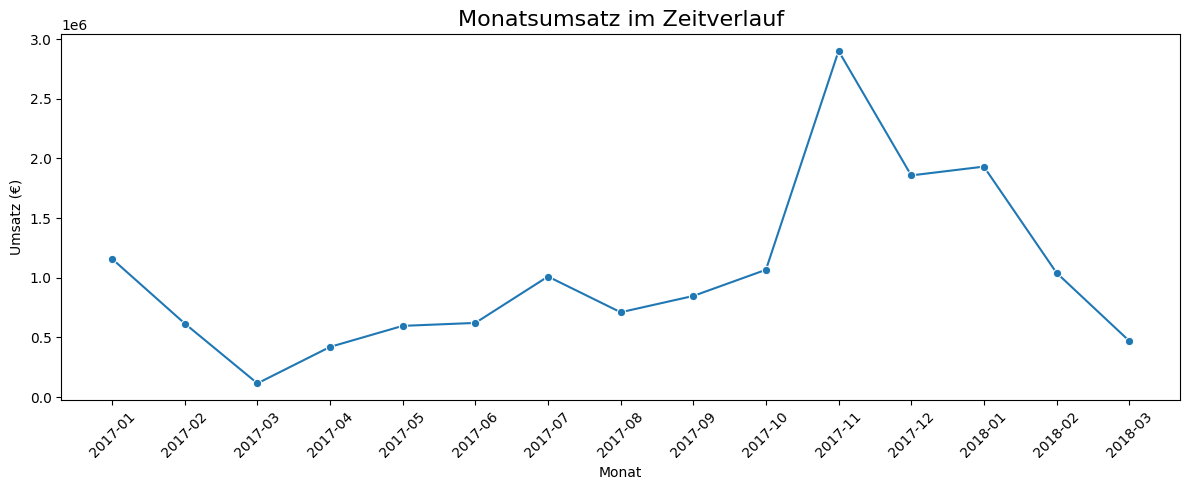

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=umsatz_monat, x=umsatz_monat["month"].astype(str), y="total_paid", ax=ax, marker="o")
ax.set_title("Monatsumsatz im Zeitverlauf", fontsize=16)
ax.set_xlabel("Monat")
ax.set_ylabel("Umsatz (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##6.Saisonale Muster
**Platzhalter — vom Team zu ergänzen:** Black-Friday-Fenster (i. d. R. letzter Freitag im November) und Weihnachtszeit (Dezember) markieren, um saisonale Umsatzspitzen sichtbar zu machen.

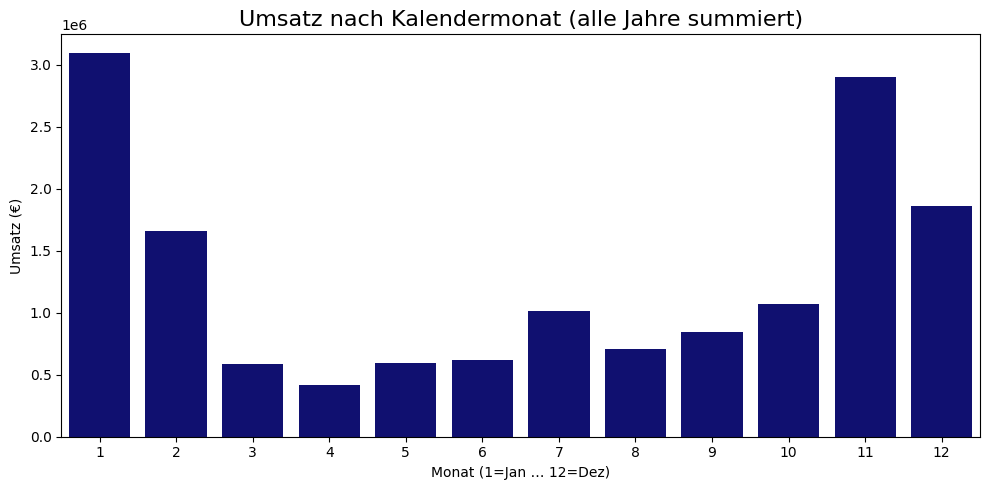

In [ ]:
orders_analyse.loc[:, 'month_num'] = orders_analyse['created_date'].dt.month
orders_analyse.loc[:, 'is_black_friday_month'] = orders_analyse['month_num'] == 11
orders_analyse.loc[:, 'is_christmas_month'] = orders_analyse['month_num'] == 12

saison_umsatz = orders_analyse.groupby('month_num', as_index=False)['total_paid'].sum()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=saison_umsatz, x='month_num', y='total_paid', ax=ax, color='navy')
ax.set_title('Umsatz nach Kalendermonat (alle Jahre summiert)', fontsize=16)
ax.set_xlabel('Monat (1=Jan … 12=Dez)')
ax.set_ylabel('Umsatz (€)')
plt.tight_layout()
plt.show()

##7.Meistverkaufte Produkte & Umsatz nach Kategorie

### 7.1.Top-10 meistverkaufte Produkte

Zur Identifikation der umsatzstärksten Produkte werden zunächst die zehn meistverkauften Produkte anhand der gesamten Verkaufsmenge ermittelt. Diese Produkte bilden die Grundlage für die folgenden Analysen.

In [ ]:
top_produkte = (
    orders_orderlines_products_analyse
    .groupby(['sku', 'name', 'category'], as_index=False)['product_quantity'].sum()
    .sort_values('product_quantity', ascending=False)
    .head(10)
)
top_produkte

,sku,name,category,product_quantity
529,APP1190,IPhone AppleCare Protection Plan,Mobile Phones,1015
409,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,Mobile Phones,831
848,APP1922,AirPods Apple Bluetooth Headset for iPhone iPa...,Audio,551
5725,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Storage & NAS,514
436,APP0927,EarPods Apple Headphones with Remote and Mic (...,Audio,493
4669,SAM0074,Samsung 850 EVO SSD Disk 500GB,Components (RAM/SSD),349
1624,CRU0051,Crucial MX300 525GB SSD Disk,Components (RAM/SSD),349
550,APP1214,Apple Magic Mouse 2,Network,283
1140,APP2446,Apple iPhone 6 32GB Space Gray,Mobile Phones,271
3369,NTE0013,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",Components (RAM/SSD),266


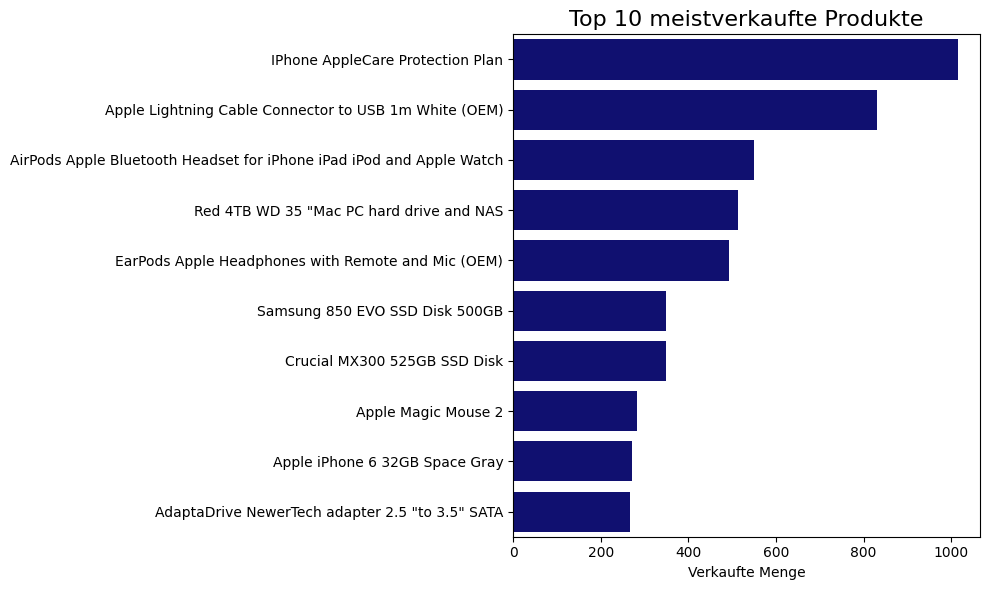

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_produkte, y='name', x='product_quantity', ax=ax, color='navy')
ax.set_title('Top 10 meistverkaufte Produkte', fontsize=16)
ax.set_xlabel('Verkaufte Menge')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Ergebnis:**

* Die Analyse zeigt, dass der größte Teil des Gesamtumsatzes von den Kategorien Computers (MacBook), Computers (iMac) und Mobile Phones erzielt wird. Die übrigen Produktkategorien tragen deutlich weniger zum Gesamtumsatz bei.

### 7.2.Bestimmung der Rabattgrenzen

Zur Einteilung der Rabattstufen werden zunächst die Verteilung der Rabatte sowie die Quartile berechnet. Die ermittelten Quartilsgrenzen dienen anschließend zur Definition der Rabattkategorien (Niedrig, Mittel und Hoch).

In [ ]:
# Deskriptive Statistik der Rabattwerte berechnen
orderlines_products_analyse["discount_percent"].describe()

,discount_percent
count,60179.00
mean,21.91
std,20.22
min,-212.27
25%,8.27
50%,17.15
75%,28.58
max,99.98


In [ ]:
# Quartile der Rabattwerte berechnen
orderlines_products_analyse["discount_percent"].quantile([0.25, 0.50, 0.75])

,discount_percent
0.25,8.27
0.50,17.15
0.75,28.58


**Ergebnis:**

* Die deskriptive Statistik zeigt, dass die Rabattwerte eine große Streuung aufweisen. Die Quartile liegen bei 8,27 % (Q1), 17,15 % (Median) und 28,58 % (Q3). Diese Werte wurden anschließend als objektive Grundlage zur Einteilung der Rabattstufen (Niedrig, Mittel und Hoch) verwendet.

### 7.3.Umsatz der Top-10-Produkte nach Rabattstufe

Im nächsten Schritt wird zunächst der Umsatz pro Bestellposition berechnet. Anschließend wird untersucht, wie sich unterschiedliche Rabattstufen auf den durchschnittlichen Umsatz der zehn meistverkauften Produkte auswirken.

In [ ]:
# =====================================================
# Umsatz je Bestellposition berechnen
# =====================================================
orders_orderlines_products_analyse["umsatz"] = (
    orders_orderlines_products_analyse["unit_price"]
    * orders_orderlines_products_analyse["product_quantity"]
)

In [ ]:
# =====================================================
# Daten für die Rabattanalyse vorbereiten
# =====================================================

# Kopie des Analysedatensatzes erstellen
q6 = orders_orderlines_products_analyse.copy()

# Nur gültige Rabattwerte (0 % bis 100 %) berücksichtigen
q6 = q6[
    (q6["discount_percent"] >= 0) &
    (q6["discount_percent"] <= 100)
].copy()

# Rabattgrenzen anhand der zuvor berechneten Quartile festlegen
LOW_LIMIT = 8.27
HIGH_LIMIT = 28.58

# Die zehn meistverkauften Produkte auswählen
q6 = q6[q6["name"].isin(top_produkte["name"])].copy()


# Rabattstufe anhand der Quartilsgrenzen bestimmen
def classify_discount(x):

    if x == 0:
        return "Kein Rabatt"

    elif x <= LOW_LIMIT:
        return "Niedrig"

    elif x <= HIGH_LIMIT:
        return "Mittel"

    else:
        return "Hoch"


# Rabattstufe jedem Datensatz zuweisen
q6["discount_level"] = q6["discount_percent"].apply(classify_discount)

In [ ]:
# =====================================================
# Durchschnittlichen Umsatz je Produkt und Rabattstufe
# berechnen
# =====================================================

umsatz_nach_rabatt = (
    q6.groupby(
        ["name", "discount_level"],
        observed=True
    )
    .agg(
        durchschnittlicher_umsatz=("umsatz", "mean")
    )
    .reset_index()
)

In [ ]:
# =====================================================
# Pivot-Tabelle für den durchschnittlichen Umsatz
# nach Rabattstufe erstellen
# =====================================================

pivot_tabelle = (
    umsatz_nach_rabatt
    .pivot(
        index="name",
        columns="discount_level",
        values="durchschnittlicher_umsatz"
    )
    .reindex(
        columns=[
            "Kein Rabatt",
            "Niedrig",
            "Mittel",
            "Hoch"
        ]
    )
    .reindex(top_produkte["name"])
)

display(pivot_tabelle.round(2))

discount_level,Kein Rabatt,Niedrig,Mittel,Hoch
name,,,,
IPhone AppleCare Protection Plan,70.00,71.31,59.38,NaN
Apple Lightning Cable Connector to USB 1m White (OEM),NaN,NaN,NaN,17.09
AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,184.51,170.69,167.00,NaN
"Red 4TB WD 35 ""Mac PC hard drive and NAS",NaN,254.13,235.41,NaN
EarPods Apple Headphones with Remote and Mic (OEM),NaN,NaN,NaN,22.10
Samsung 850 EVO SSD Disk 500GB,NaN,168.54,168.06,NaN
Crucial MX300 525GB SSD Disk,NaN,177.58,156.12,NaN
Apple Magic Mouse 2,89.00,88.12,85.62,NaN
Apple iPhone 6 32GB Space Gray,NaN,NaN,402.08,NaN


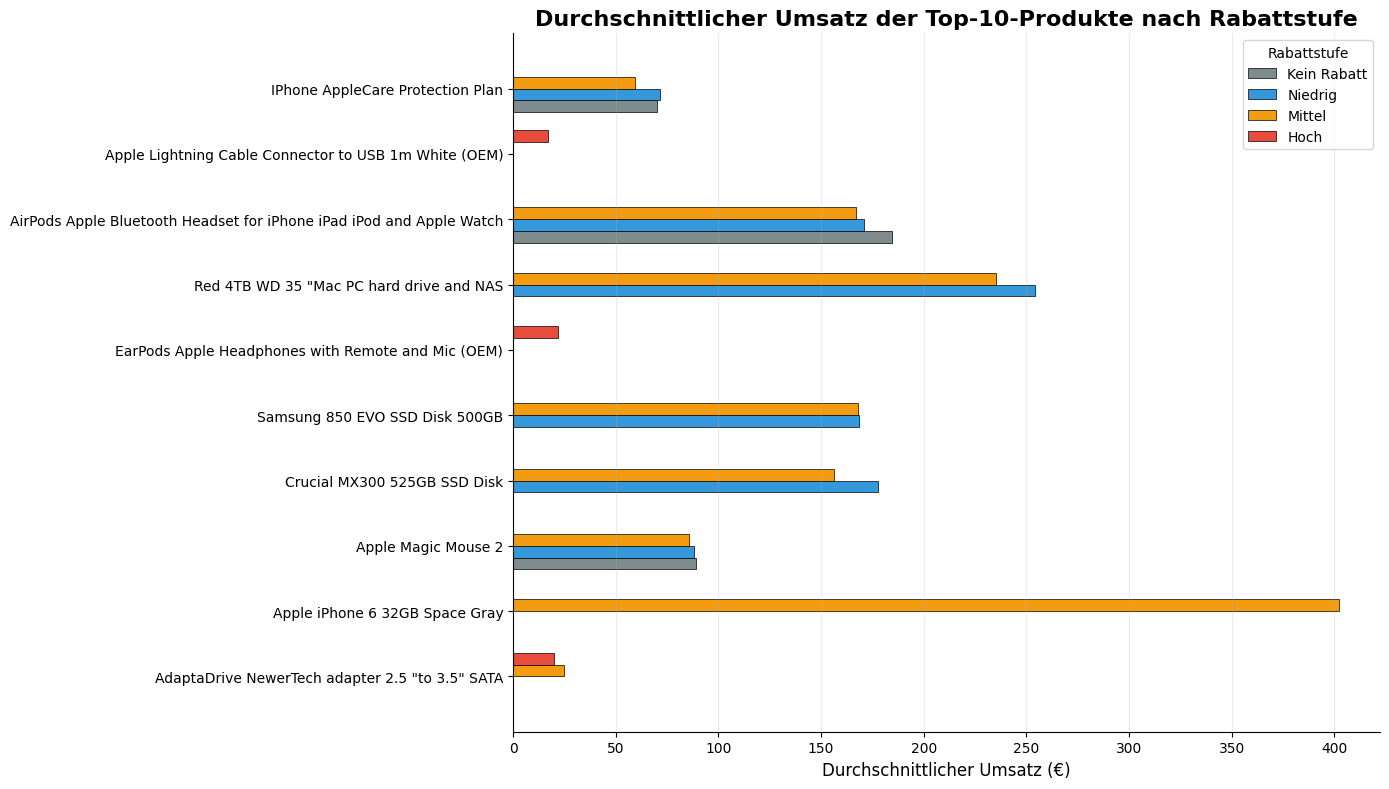

In [ ]:
# =====================================================
# Balkendiagramm der Top-10-Produkte nach Rabattstufe
# erstellen
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# Fehlende Werte durch 0 ersetzen und Reihenfolge umkehren
plot_data = pivot_tabelle.fillna(0).iloc[::-1]

# Abbildung erstellen
fig, ax = plt.subplots(figsize=(14, 8))

# Positionen und Balkenhöhe festlegen
y = np.arange(len(plot_data))
height = 0.18

# Reihenfolge der Rabattstufen
rabattstufen = [
    "Kein Rabatt",
    "Niedrig",
    "Mittel",
    "Hoch"
]

# Farben der Rabattstufen festlegen
farben = {
    "Kein Rabatt": "#7F8C8D",
    "Niedrig": "#3498DB",
    "Mittel": "#F39C12",
    "Hoch": "#E74C3C"
}

# Versatz der Balken innerhalb jeder Produktgruppe
offsets = [-0.27, -0.09, 0.09, 0.27]

# Balken für jede Rabattstufe zeichnen
for rabattstufe, offset in zip(rabattstufen, offsets):

    if rabattstufe in plot_data.columns:

        ax.barh(
            y + offset,
            plot_data[rabattstufe],
            height=height,
            color=farben[rabattstufe],
            label=rabattstufe,
            edgecolor="black",
            linewidth=0.5
        )

# Achsenbeschriftungen festlegen
ax.set_yticks(y)

ax.set_yticklabels(
    plot_data.index,
    fontsize=10
)

ax.set_xlabel(
    "Durchschnittlicher Umsatz (€)",
    fontsize=12
)

# Diagrammtitel festlegen
ax.set_title(
    "Durchschnittlicher Umsatz der Top-10-Produkte nach Rabattstufe",
    fontsize=16,
    fontweight="bold"
)

# Legende hinzufügen
ax.legend(
    title="Rabattstufe",
    loc="upper right"
)

# Gitternetz nur auf der x-Achse anzeigen
ax.grid(
    axis="x",
    alpha=0.25
)

# Oberen und rechten Rahmen ausblenden
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Layout optimieren
plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "Top10_Produkte_nach_Rabattstufe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
# Diagramm anzeigen
plt.show()

**Ergebnis:**

* Die Auswertung zeigt, dass sich der durchschnittliche Umsatz der Top-10-Produkte je nach Rabattstufe unterschiedlich entwickelt. Einige Produkte erzielen bereits ohne oder mit niedrigen Rabatten hohe Umsätze, während andere ihren höchsten durchschnittlichen Umsatz erst bei mittleren oder hohen Rabatten erreichen. Ein einheitlicher Zusammenhang zwischen Rabattstufe und Umsatz ist nicht erkennbar.

### 7.4.Vergleich der Top-10-Produkte in Peak- und Normalmonaten

Zum Abschluss wird untersucht, wie sich Umsatz, Verkaufsmenge und durchschnittlicher Rabatt der Top-10-Produkte zwischen Peak-Monaten (November bis Januar) und den übrigen Monaten unterscheiden.

In [ ]:
# =====================================================
# Daten für die Analyse der Top-10-Produkte vorbereiten
# =====================================================

# Kopie des Analysedatensatzes erstellen
q5 = orders_orderlines_products_analyse.copy()

# Die zehn meistverkauften Produkte auswählen
top_10_skus = top_produkte["sku"].tolist()

q5 = q5[
    q5["sku"].isin(top_10_skus)
].copy()

# =====================================================
# Peak- und Normalmonate definieren
# =====================================================

peak_monate = ["Nov", "Dez", "Jan"]

# Datumsformat umwandeln
q5["date"] = pd.to_datetime(q5["date"])

# Monatsnamen erzeugen
q5["monat_name"] = q5["date"].dt.strftime("%b")

# Saison anhand des Monats bestimmen
q5["saison"] = q5["monat_name"].apply(
    lambda x: "Peak" if x in peak_monate else "Normal"
)

# =====================================================
# Monatliche Kennzahlen der Top-10-Produkte berechnen
# =====================================================

q5_monthly = (
    q5.groupby(
        ["saison", "monat_name"],
        as_index=False
    )
    .agg(
        monatsumsatz=("umsatz", "sum"),
        monatsverkaufsmenge=("product_quantity", "sum"),
        durchschnittlicher_rabatt=("discount_percent", "mean")
    )
)

# =====================================================
# Durchschnittswerte je Saison berechnen
# =====================================================

q5_result = (
    q5_monthly.groupby(
        "saison",
        as_index=False
    )
    .agg(
        durchschnittlicher_monatsumsatz=(
            "monatsumsatz",
            "mean"
        ),
        durchschnittliche_monatsverkaufsmenge=(
            "monatsverkaufsmenge",
            "mean"
        ),
        durchschnittlicher_rabatt=(
            "durchschnittlicher_rabatt",
            "mean"
        )
    )
)

# Werte auf zwei Nachkommastellen runden
q5_result = q5_result.round(2)

# Ergebnistabelle anzeigen
display(q5_result)

,saison,durchschnittlicher_monatsumsatz,durchschnittliche_monatsverkaufsmenge,durchschnittlicher_rabatt
0,Normal,29330.86,272.80,24.22
1,Peak,86063.03,1097.00,28.18


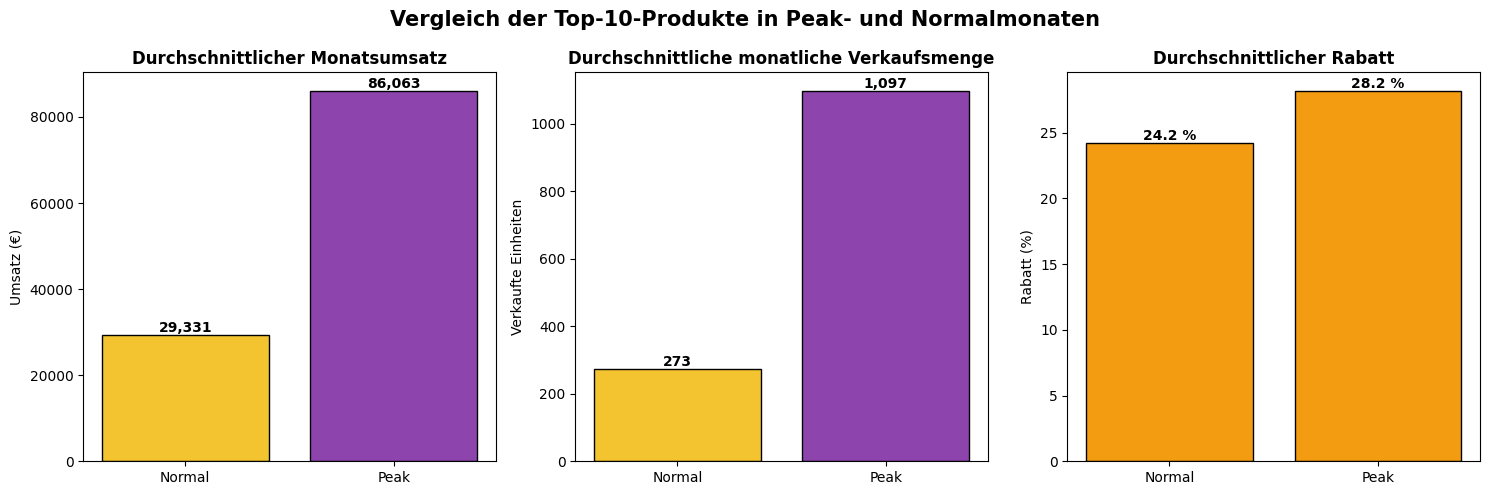

In [ ]:
import matplotlib.pyplot as plt

# =====================================================
# Farben für die Diagramme festlegen
# =====================================================

normal_farbe = "#F4C430"
peak_farbe = "#8E44AD"
rabatt_farbe = "#F39C12"

# =====================================================
# Abbildung mit drei Diagrammen erstellen
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# =====================================================
# Durchschnittlicher Monatsumsatz
# =====================================================

balken1 = axes[0].bar(
    q5_result["saison"],
    q5_result["durchschnittlicher_monatsumsatz"],
    color=[normal_farbe, peak_farbe],
    edgecolor="black"
)

axes[0].set_title(
    "Durchschnittlicher Monatsumsatz",
    fontweight="bold"
)

axes[0].set_ylabel("Umsatz (€)")

# Umsatzwerte über den Balken anzeigen
for balken in balken1:

    hoehe = balken.get_height()

    axes[0].text(
        balken.get_x() + balken.get_width() / 2,
        hoehe,
        f"{hoehe:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# =====================================================
# Durchschnittliche monatliche Verkaufsmenge
# =====================================================

balken2 = axes[1].bar(
    q5_result["saison"],
    q5_result["durchschnittliche_monatsverkaufsmenge"],
    color=[normal_farbe, peak_farbe],
    edgecolor="black"
)

axes[1].set_title(
    "Durchschnittliche monatliche Verkaufsmenge",
    fontweight="bold"
)

axes[1].set_ylabel("Verkaufte Einheiten")

# Verkaufsmenge über den Balken anzeigen
for balken in balken2:

    hoehe = balken.get_height()

    axes[1].text(
        balken.get_x() + balken.get_width() / 2,
        hoehe,
        f"{hoehe:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# =====================================================
# Durchschnittlicher Rabatt
# =====================================================

balken3 = axes[2].bar(
    q5_result["saison"],
    q5_result["durchschnittlicher_rabatt"],
    color=[rabatt_farbe, rabatt_farbe],
    edgecolor="black"
)

axes[2].set_title(
    "Durchschnittlicher Rabatt",
    fontweight="bold"
)

axes[2].set_ylabel("Rabatt (%)")

# Rabattwerte über den Balken anzeigen
for balken in balken3:

    hoehe = balken.get_height()

    axes[2].text(
        balken.get_x() + balken.get_width() / 2,
        hoehe,
        f"{hoehe:.1f} %",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# =====================================================
# Gesamttitel und Layout festlegen
# =====================================================

plt.suptitle(
    "Vergleich der Top-10-Produkte in Peak- und Normalmonaten",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Ergebnis:**

* Die Analyse zeigt, dass die Top-10-Produkte in den Peak-Monaten deutlich höhere Umsätze und Verkaufsmengen erzielen als in den Normalmonaten. Gleichzeitig ist auch der durchschnittliche Rabatt in der Peak-Saison etwas höher. Dies deutet darauf hin, dass die saisonale Nachfrage einen starken Einfluss auf die Verkaufsleistung hat.

In [ ]:
orders_orderlines_products_analyse['umsatz'] = (
    orders_orderlines_products_analyse['product_quantity'] * orders_orderlines_products_analyse['unit_price']
)
umsatz_kategorie = (
    orders_orderlines_products_analyse
    .groupby('category', as_index=False)['umsatz'].sum()
    .sort_values('umsatz', ascending=False)
)
umsatz_kategorie

,category,umsatz
4,Computers (MacBook),3738808.65
5,Computers (iMac),2425451.20
7,Mobile Phones,2336983.17
13,Storage & NAS,1927452.68
2,Components (RAM/SSD),1286989.11
14,Tablets,975898.17
8,Monitors,811600.66
0,Accessories & Cables,656216.57
1,Audio,415234.09
15,Wearables,261851.69


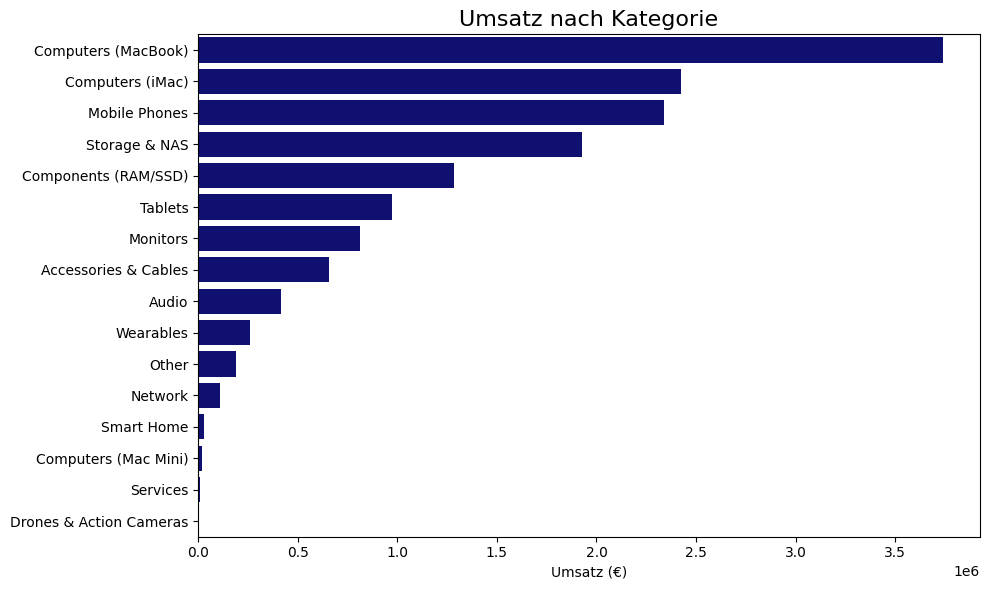

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=umsatz_kategorie, y='category', x='umsatz', ax=ax, color='navy')
ax.set_title('Umsatz nach Kategorie', fontsize=16)
ax.set_xlabel('Umsatz (€)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Ergebnis:**

* Die Analysen zeigen, dass sich ein großer Teil der Verkaufsmenge und des Umsatzes auf wenige Bestseller konzentriert. Insbesondere Apple-Produkte dominieren die Top-10-Liste.
* Zwischen Rabattstufe und durchschnittlichem Umsatz konnte kein eindeutiger Zusammenhang festgestellt werden. Die Wirkung von Rabatten unterscheidet sich deutlich zwischen den einzelnen Produkten.
* In den Peak-Monaten liegen der durchschnittliche Monatsumsatz, die Verkaufsmenge und auch der durchschnittliche Rabatt deutlich höher als in den Normalmonaten.
* Die höchsten Gesamtumsätze werden von den Produktkategorien Computers (MacBook), Computers (iMac) und Mobile Phones erzielt.

**Vermutung:**

* Der Verkaufserfolg wird nicht ausschließlich durch Rabatte beeinflusst. Auch Produkttyp, Markenstärke und die saisonale Nachfrage spielen eine wichtige Rolle.
* Die höheren Umsätze während der Peak-Monate sind vermutlich auf die Kombination aus einer erhöhten Kundennachfrage und gezielten Rabattaktionen zurückzuführen.

**Pro Marketing:**

* Gezielte Rabattaktionen können insbesondere während der Peak-Saison den Verkauf zusätzlich fördern.
* Die Ergebnisse sprechen dafür, Rabatte gezielt, differenziert und produktspezifisch einzusetzen, anstatt für alle Produkte dieselbe Rabattstrategie anzuwenden.
* Besonders umsatzstarke Produktkategorien bieten ein hohes Potenzial für gezielte Marketingmaßnahmen.

**Contra Vorstand:**

* Höhere Rabatte führen nicht automatisch zu höheren Umsätzen.
* Die Rabattwirkung ist von Produkt zu Produkt unterschiedlich und kann daher nicht verallgemeinert werden.
* Auf Grundlage der vorliegenden Daten lässt sich nicht beurteilen, ob höhere Umsätze gleichzeitig auch zu höheren Gewinnen führen, da Informationen zu Einkaufspreisen, Gewinnmargen und Deckungsbeiträgen fehlen.

**Fazit:**

* Die Analysen zeigen, dass Umsatz, Rabatt und Saison in einem komplexen Zusammenhang stehen. Während saisonale Rabattaktionen und gezielte Marketingmaßnahmen den Verkauf einzelner Produkte unterstützen können, ist eine einheitliche Rabattstrategie für alle Produkte nicht sinnvoll. Stattdessen erscheint eine differenzierte, produkt- und saisonabhängige Rabattstrategie am geeignetsten. Für eine abschließende wirtschaftliche Bewertung wären zusätzlich Informationen zu Einkaufspreisen, Gewinnmargen und Deckungsbeiträgen erforderlich.

###8.1.Rabattanalyse – Kernfrage
**Nimmt der Umsatz mit steigenden Rabatten zu?**

###8.2.Rabattstufen/ Rabattkategorien vs eindeutige Bestellung

In [ ]:
# Aufteilen der prozentualen Rabatte in 10%-Schritte (Bereiche).
m = orders_orderlines_products_analyse # m ist ab jetzt die Kurzform für diese Tabelle
                   # pd.cut ist eine Funktion aus der Python-Bibliothek Pandas.Sie schneidet (kategorisiert) kontinuierliche Zahlenwerte in feste Intervalle
                             # Das ist die Ausgangsspalte, die die exakten Rabatte enthält (z. B. 5, 12 oder 25).
                                                   #Definiert die Grenzen der Intervalle.range(0, 110, 10) erzeugt die Zahlen: 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100.
m['rabatt_bucket'] = pd.cut(m['discount_percent'], bins=range(0, 110, 10))
# Daraus entstehen die Gruppen: (0, 10], (10, 20], (20, 30] bis (90, 100].
m['rabatt_bucket']


,rabatt_bucket
0,"(0, 10]"
1,"(40, 50]"
2,"(20, 30]"
3,"(10, 20]"
4,"(40, 50]"
...,...
60174,"(60, 70]"
60175,"(60, 70]"
60176,"(60, 70]"
60177,"(60, 70]"


In [ ]:
# Anzahl der eindeutigen Bestellungen je Rabattstufe
bestellungen_je_rabatt = m.groupby('rabatt_bucket', observed=True, as_index=False)['id_order'].nunique()
bestellungen_je_rabatt

,rabatt_bucket,id_order
0,"(0, 10]",12024
1,"(10, 20]",15090
2,"(20, 30]",11421
3,"(30, 40]",4514
4,"(40, 50]",2768
5,"(50, 60]",1965
6,"(60, 70]",1665
7,"(70, 80]",910
8,"(80, 90]",406
9,"(90, 100]",1038


In [ ]:
umsatz_je_rabatt = m.groupby('rabatt_bucket', observed=True, as_index=False)['umsatz'].sum()
menge_je_rabatt = m.groupby('rabatt_bucket', observed=True, as_index=False)['product_quantity'].sum()
menge_je_rabatt

,rabatt_bucket,product_quantity
0,"(0, 10]",14577
1,"(10, 20]",18598
2,"(20, 30]",13923
3,"(30, 40]",5251
4,"(40, 50]",3211
5,"(50, 60]",2305
6,"(60, 70]",2137
7,"(70, 80]",1062
8,"(80, 90]",468
9,"(90, 100]",1178


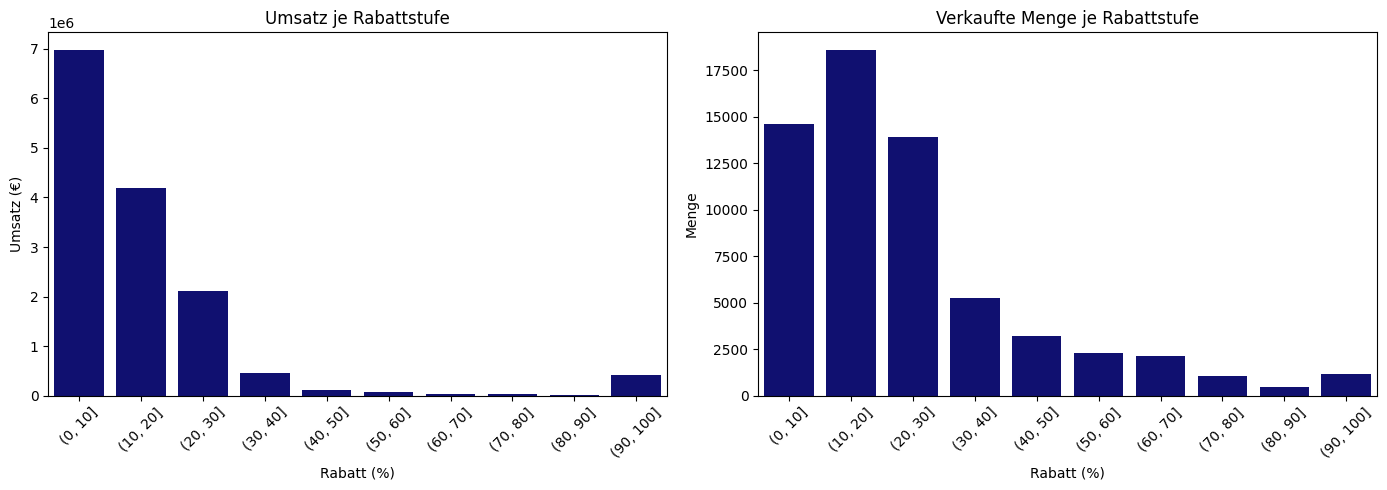

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=umsatz_je_rabatt, x='rabatt_bucket', y='umsatz', ax=axes[0], color='navy')
axes[0].set_title('Umsatz je Rabattstufe')
axes[0].set_xlabel('Rabatt (%)')
axes[0].set_ylabel('Umsatz (€)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=menge_je_rabatt, x='rabatt_bucket', y='product_quantity', ax=axes[1], color='navy')
axes[1].set_title('Verkaufte Menge je Rabattstufe')
axes[1].set_xlabel('Rabatt (%)')
axes[1].set_ylabel('Menge')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Gesamtzahl eindeutiger Bestellungen in m, OHNE Gruppierung nach Rabattstufe – Vergleichswert zur Überschneidungsprüfung
m['id_order'].nunique()

45418

**Ergebnis:**

- 51.801 > 45.418 → Bestätigt: Es gibt eine Überschneidung von 51.801 − 45.418 = 6.383 Mehrfachzählungen (≈ 14 % der Bestellungen tauchen in mehr als einem Rabatt-Bucket auf).
- Das heißt: viele Bestellungen enthalten Produkte aus mehreren Rabattstufen. Beispiel: Das heißt: Wenn eine Bestellung z. B. ein Produkt mit 5 % Rabatt UND ein Produkt mit 45 % Rabatt enthält, taucht diese eine Bestellung sowohl im Bucket (0,10] als auch im Bucket (40,50] auf — sie wird doppelt gezählt, wenn man die Spalten-Summe bildet.

=> keine klare Aussage für den Vorstand. Es ist notwendig Rabatt pro Bestellung erst mitteln (Ø discount_percent je id_order), dann DIESEN Wert in Buckets einteilen. Jede Bestellung landet dann in genau einem Bucket.

###8.3. Rabatt pro Bestellung mitteln

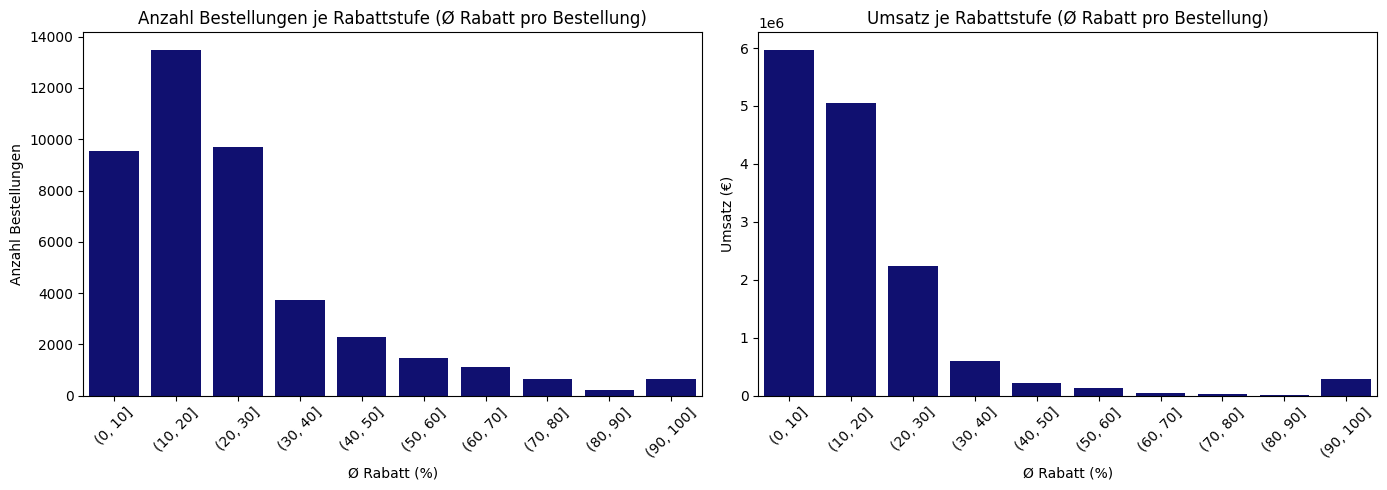

In [ ]:
# Ø Rabatt je Bestellung berechnen - eine Zeile pro id_order statt pro Position, vermeidet Doppelzählung
# Ergebnis: Rabatt nicht mehr pro Position, sondern pro Bestellung gemittelt — jede Bestellung erscheint danach nur noch einmal
rabatt_je_bestellung = m.groupby('id_order', as_index=False)['discount_percent'].mean()

# Umsatz und Bestellanzahl ebenfalls auf Bestellungs-Ebene aggregieren (nicht Positions-Ebene)
#Ergebnis: Umsatz je Bestellung aufsummiert (falls mehrere Produkte pro Bestellung)
umsatz_je_bestellung = m.groupby('id_order', as_index=False)['umsatz'].sum()

# Die drei Bestellungs-Kennzahlen (Ø Rabatt, Umsatz) in einer Tabelle zusammenführen
# Beide Ergebnisse in einer Tabelle zusammengeführt, verknüpft über id_order
bestellungen_df = rabatt_je_bestellung.merge(umsatz_je_bestellung, on='id_order')

# Rabatt-Buckets in 10%-Schritten bilden, jetzt auf Basis des Ø Rabatts pro Bestellung (keine Überschneidung mehr)
# Ergebnis: Ø Rabatt je Bestellung in 10 %-Schritten in Kategorien (Buckets) einteilen
bestellungen_df['rabatt_bucket'] = pd.cut(bestellungen_df['discount_percent'], bins=range(0, 110, 10))

# Je Bucket: Anzahl Bestellungen zählen und Umsatz summieren - beide Kennzahlen nebeneinander für den Vorstands-Vergleich
#Ergebnis: Je Rabattstufe zwei Kennzahlen gleichzeitig berechnen: Anzahl Bestellungen (count) und Gesamtumsatz (sum)
kernfrage_df = bestellungen_df.groupby('rabatt_bucket', observed=True, as_index=False).agg(
    anzahl_bestellungen=('id_order', 'count'),
    umsatz=('umsatz', 'sum')
)

# Zwei Diagramme nebeneinander: links Bestellanzahl (Vorstands-Argument "Auftragseingänge"), rechts Umsatz
#Ergebnis: Eine Bildfläche mit zwei Diagrammen nebeneinander vorbereiten
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm: Anzahl Bestellungen je Rabattstufe
# Ergebnis: Linkes Diagramm: Balken zeigt Bestellanzahl je Rabattstufe
sns.barplot(data=kernfrage_df, x='rabatt_bucket', y='anzahl_bestellungen', ax=axes[0], color='navy')
# Beschriftung des linken Diagramms (Titel, Achsen, gedrehte x-Beschriftung zur Lesbarkeit)
axes[0].set_title('Anzahl Bestellungen je Rabattstufe (Ø Rabatt pro Bestellung)')
axes[0].set_xlabel('Ø Rabatt (%)')
axes[0].set_ylabel('Anzahl Bestellungen')
axes[0].tick_params(axis='x', rotation=45)

# Balkendiagramm: Umsatz je Rabattstufe
# Ergebnis: Rechtes Diagramm: Balken zeigt Umsatz je Rabattstufe
sns.barplot(data=kernfrage_df, x='rabatt_bucket', y='umsatz', ax=axes[1], color='navy')
# Beschriftung des rechten Diagramms
axes[1].set_title('Umsatz je Rabattstufe (Ø Rabatt pro Bestellung)')
axes[1].set_xlabel('Ø Rabatt (%)')
axes[1].set_ylabel('Umsatz (€)')
axes[1].tick_params(axis='x', rotation=45)

#Abstände zwischen den beiden Diagrammen automatisch optimieren, damit nichts überlappt
plt.tight_layout()

#Diagramm anzeigen
plt.show()

In [ ]:
korrelation = m[['discount_percent', 'product_quantity']].corr()
korrelation

,discount_percent,product_quantity
discount_percent,1.00,0.01
product_quantity,0.01,1.00


###8.4.Zusatzanalyse: Rabatthöhe nach Kategorie
Unterstützt die Frage, ob bestimmte Produktgruppen überproportional rabattiert werden (relevant für die Positionierungsfrage des Vorstands).

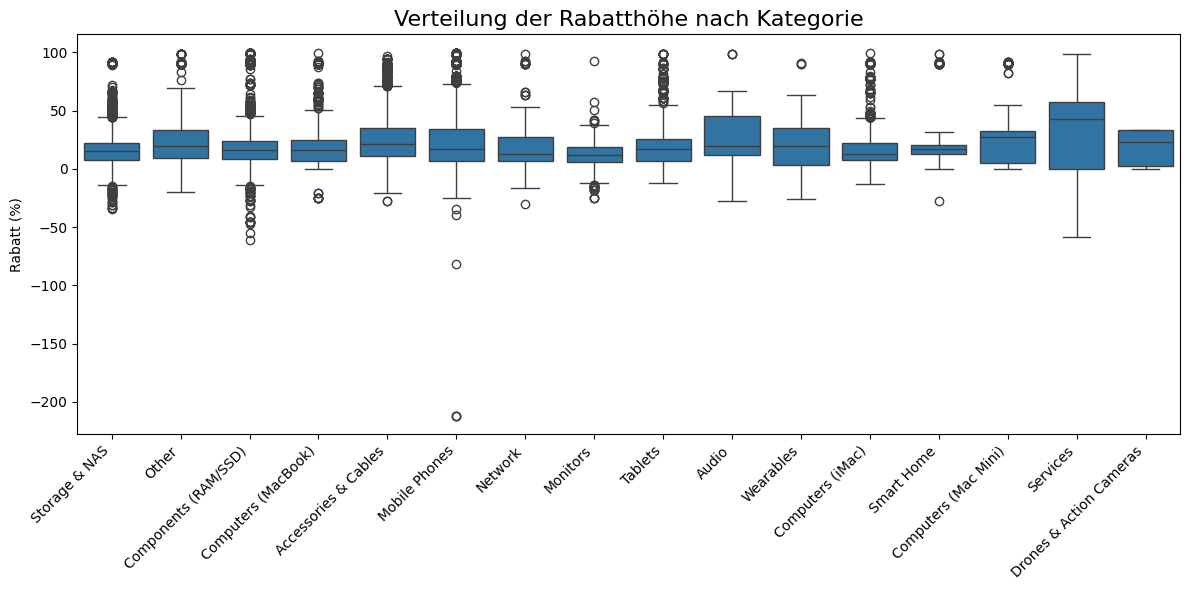

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=m, x='category', y='discount_percent', ax=ax)
ax.set_title('Verteilung der Rabatthöhe nach Kategorie', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('Rabatt (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

####8.4.1.Strategische Rabattanalyse nach Kategorie

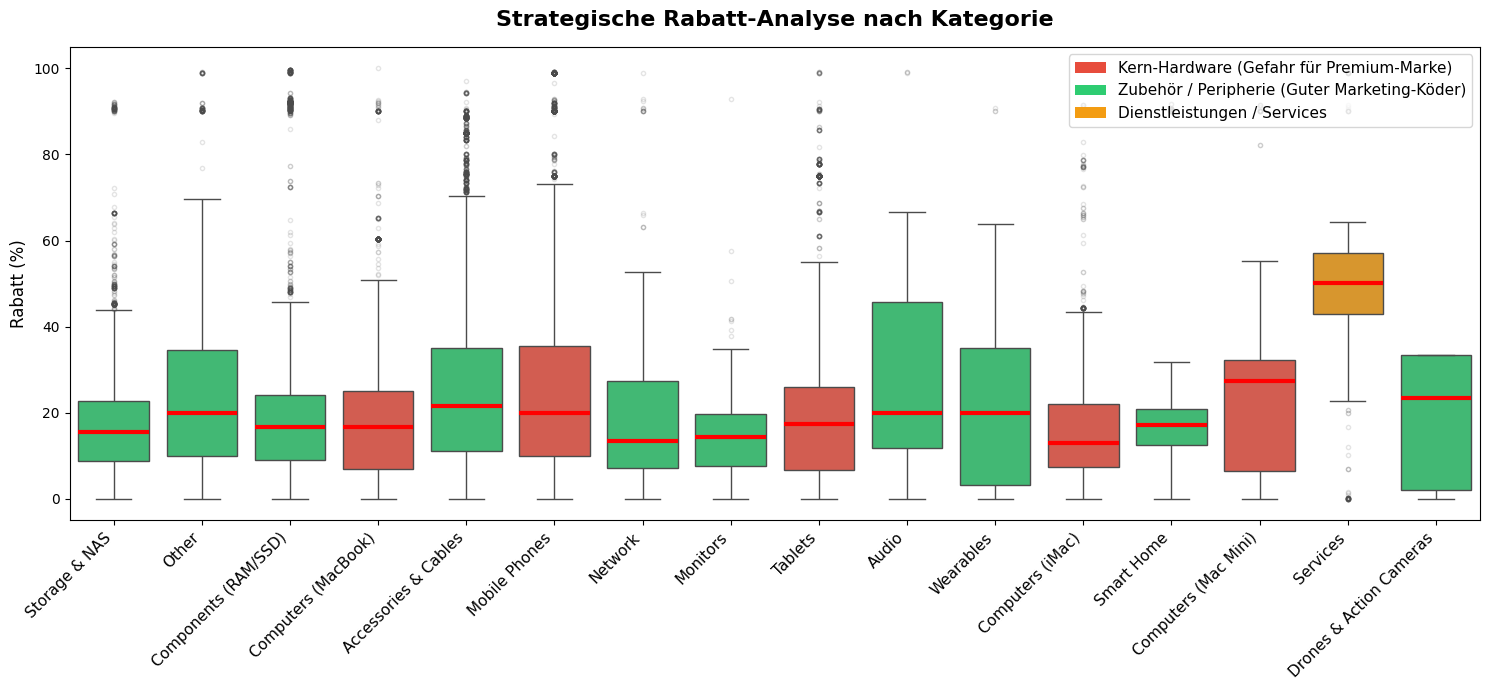

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Datenbereinigung (Negative Werte ausschließen)
m_clean = m[(m['discount_percent'] >= 0) & (m['discount_percent'] <= 100)]

# 2. Logik für die Pro/Contra-Einfärbung definieren
# Wir trennen in Core-Hardware (Contra) und Zubehör/Sonstiges (Pro)
def get_color(cat):
    contra_categories = ['Computers (MacBook)', 'Computers (iMac)', 'Computers (Mac Mini)', 'Mobile Phones', 'Tablets']
    if cat in contra_categories:
        return '#e74c3c'  # Signal-Rot (Gefährlich für die Premium-Marke)
    elif cat == 'Services':
        return '#f39c12'  # Orange (Sonderfall)
    else:
        return '#2ecc71'  # Grün (Unbedenkliches Zubehör / Marketing-Köder)

# Farb-Palette für die Grafik erstellen
unique_categories = m_clean['category'].unique()
colors = [get_color(cat) for cat in unique_categories]

# 3. Diagramm erstellen
fig, ax = plt.subplots(figsize=(15, 7))

# Boxen plotten mit optimierten Ausreißern (kleiner & transparent)
sns.boxplot(
    data=m_clean,
    x='category',
    y='discount_percent',
    ax=ax,
    palette=colors,
    hue='category',     # Verhindert Warnmeldungen in neueren Seaborn-Versionen
    legend=False,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.15, 'color': 'gray'}, # Saubere Ausreißer
    medianprops={'color': 'red', 'linewidth': 3}  # Fetter, roter Median-Strich!
)

# Titel und Achsen
ax.set_title('Strategische Rabatt-Analyse nach Kategorie', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Rabatt (%)', fontsize=12)
ax.set_ylim(-5, 105)

# Legende manuell hinzufügen für die Pro/Contra-Argumentation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Kern-Hardware (Gefahr für Premium-Marke)'),
    Patch(facecolor='#2ecc71', label='Zubehör / Peripherie (Guter Marketing-Köder)'),
    Patch(facecolor='#f39c12', label='Dienstleistungen / Services')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

**Ergebnis:**

- Blick auf die roten Boxen (z. B. MacBooks, iPhones), wie hoch der Preisdruck auf die Kernprodukte von Apple wirklich ist.

**Vermutung:**
- Die Ausreißer-Punkte bei manchen Produkten auf der 100%-Linie. „Das sind keine echten Rabatte, sondern vermutlich systemische Fehler oder Gratis-Zugaben.“
**Contra Vorstand: **

- Dienstleistungen haben im Apple-Umsfeld die höchste Marge. Bei standardmäßig massiven Rabatten(breite Box), verschenken wir bares Geld bei Produkten, die gar keinem direkten Hardware-Preiskampf am Markt unterliegen.
Ausreißer Wir verschenken teure Apple-Hardware! Entweder bucht das Marketing im System Gratis-Geräte als „Rabatt“ (was die Marge ruiniert) oder unsere Datenqualität im System ist so schlecht.

**Pro Marketing:**
- Flache Boxen für Computers (MacBook), Computers (iMac) und Mobile Phones Bei der teuren Kernhardware verramschen wir nichts. Die Preisreduzierungen bewegen sich in einem absolut üblichen, marktkonformen Rahmen für Elektronik. Der Premium-Markenwert von Apple wird hier eben nicht beschädigt.
- zubehör-Box etwas höher und Ausreißer streuen. so muss eine Promotion-Strategie aussehen. Bei Kabeln, Hüllen und Adaptern nutzen wir die elastische Nachfrage. Höhere Rabatte locken die Kunden in den Shop (Warenkorb-Köder), wo sie dann die margenstarke Hardware zum fast vollen Preis kaufen.

**Fazit:**
Das Diagramm zeigt: Der Preiskampf findet nicht bei den Flaggschiff-Produkten (MacBooks/iPhones) statt, sondern im Zubehör- und Dienstleistungsbereich. Die Sorge der Investoren, dass wir die Marke Apple bei uns verramschen, lässt sich mit den flachen Hardware-Boxen faktenbasiert entkräften.

**Pro- & Contra-Argumentation(Für den Abschlussbericht)**
- Mangels Kostendaten kann der Bericht nicht final gelösen werden.
- Strategische Einschränkung und Handlungsempfehlung
  - CONTRA (Kritik an beiden Lagern)
    Weder das Marketing (mit dem Argument "mehr Aufträge/Wachstum") noch
    die Investoren (mit dem Argument "Qualitätssegment schützt Umsatz") können ihre Hypothese mathematisch beweisen.
    Am Ende zählen nur die harten Deckungsbeiträge.
  - PRO
    „Wir haben die Umsatz- und Volumenstrukturen offengelegt. Um die Debatte endgültig zu klären, muss das Data-Team im nächsten Schritt Zugriff auf die Einkaufspreise (Kosten) erhalten, um den tatsächlichen ROI (Return on Investment) je Rabattstufe zu berechnen.“

###8.5.Zusatzanalyse: Entwicklung des durchschnittlichen Rabatts über die Zeit
Zeigt, ob Eniac im Zeitverlauf zunehmend stärker rabattiert hat (Trend-Indikator für die Vorstands-Position "Rabatt-Spirale").

Tese: Wenn der durchschnittliche Rabatt zu bestimmten Feiertagen (z. B. Black Friday) explodiert, aber der Umsatz danach einbricht, wäre das der Beweis für einen Kaufeffekt (Pre-buying). Also der Kunde zieht seinen Kauf den er sowiso getätigen hätte einfach vor.
Beispiel: Der Kunde wollte sich im Januar ein neues MacBook zum Vollpreis kaufen. Da das Marketing aber im November (Black Friday) einen fetten Rabatt anbietet, kauft er es eben im November.

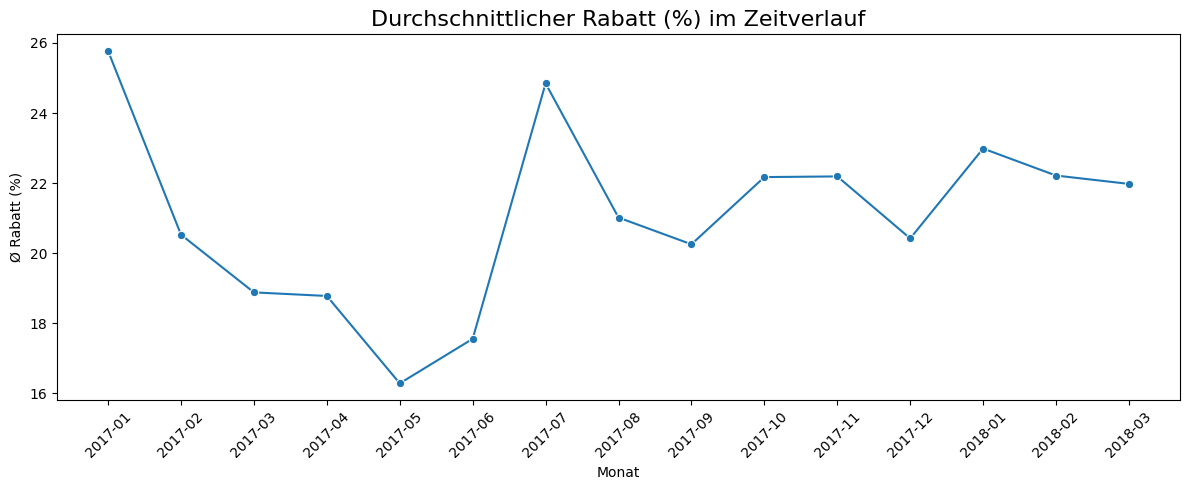

In [ ]:
m['created_date'] = pd.to_datetime(m['created_date'])
m['month'] = m['created_date'].dt.to_period('M')
rabatt_trend = m.groupby('month', as_index=False)['discount_percent'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=rabatt_trend, x=rabatt_trend['month'].astype(str), y='discount_percent', marker='o', ax=ax)
ax.set_title('Durchschnittlicher Rabatt (%) im Zeitverlauf', fontsize=16)
ax.set_xlabel('Monat')
ax.set_ylabel('Ø Rabatt (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ergebnis: **

- Die Verfälschung durch Billigartikel: Wenn im November 1.000 Kabel mit 50 % Rabatt und nur 10 Macs mit 5 % Rabatt verkauft werden, zieht der Code den Durchschnitt künstlich nach oben. Es sieht nach einer Rabatt-Explosion aus, obwohl die teure Hardware kaum rabattiert wurde.
- Währung vs. Prozent: Dem Vorstand ist es egal, ob der Prozentwert steigt. Er will wissen, wie viel Umsatzeinfluss (in Euro) die Rabatte im Zeitverlauf hatten.

In [ ]:
##8.3.Zusatzanalyse: Kaufeffekt

/tmp/ipykernel_2370/2708658862.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(trend_data['month_str'], rotation=45, ha='right')


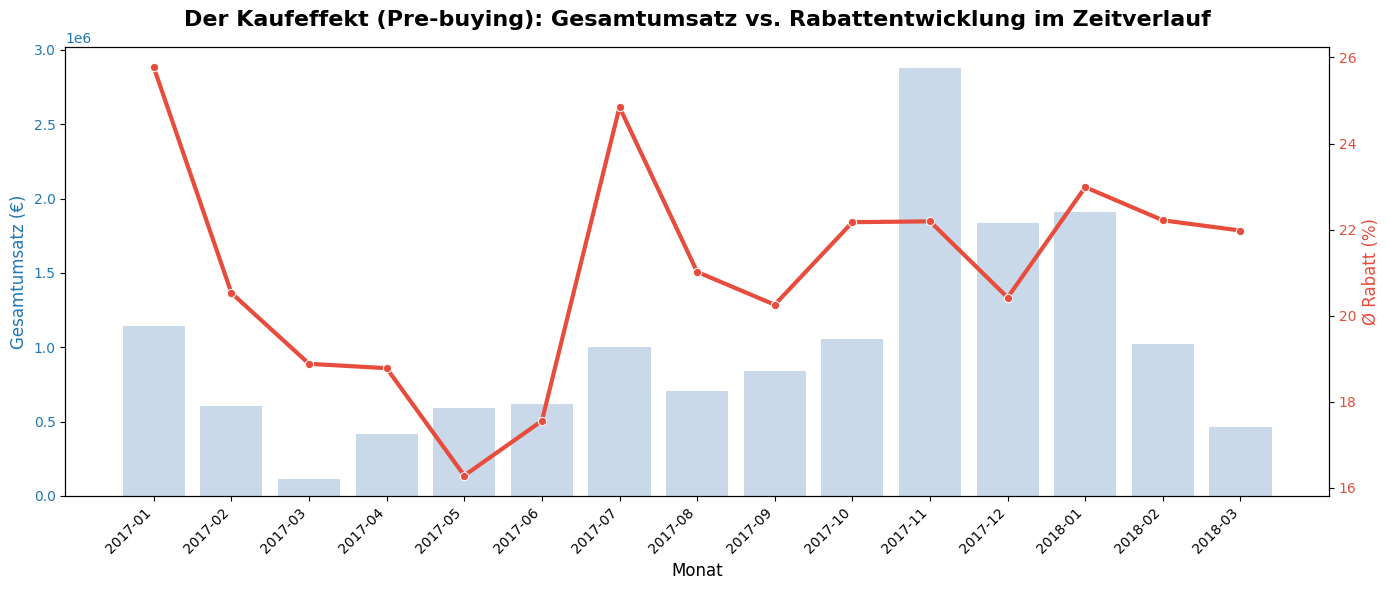

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Datentypen korrigieren und Monat extrahieren
m['created_date'] = pd.to_datetime(m['created_date'])
m['month'] = m['created_date'].dt.to_period('M')

# 2. Umsatzgewichteten Rabatt und Gesamtumsatz berechnen
# (Verhindert, dass Kleinkram-Rabatte die teuren Macs verfälschen)
trend_data = m.groupby('month', as_index=False).agg(
    gesamt_umsatz=('umsatz', 'sum'),
    gewicheter_rabatt=('discount_percent', 'mean') # oder falls vorhanden: (Rabatt_Euro / Vollpreis_Euro) * 100
)

# Monat für die X-Achse als String konvertieren
trend_data['month_str'] = trend_data['month'].astype(str)

# 3. Diagramm mit ZWEI Y-Achsen erstellen (Umsatz vs. Rabatt)
fig, ax1 = plt.subplots(figsize=(14, 6))

# A) Balkendiagramm für den Umsatz (Linke Achse)
sns.barplot(data=trend_data, x='month_str', y='gesamt_umsatz', ax=ax1, color='#abc9ea', alpha=0.7)
ax1.set_ylabel('Gesamtumsatz (€)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Monat', fontsize=12)

# B) Zweite Achse für die Rabatt-Linie (Rechte Achse)
ax2 = ax1.twinx()
sns.lineplot(data=trend_data, x='month_str', y='gewicheter_rabatt', marker='o', color='#e74c3c', linewidth=3, ax=ax2)
ax2.set_ylabel('Ø Rabatt (%)', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Titel und Layout
plt.title('Der Kaufeffekt (Pre-buying): Gesamtumsatz vs. Rabattentwicklung im Zeitverlauf', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticklabels(trend_data['month_str'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Ergebnis:**

Beweis für Vorzieheffekt / VORSTAND:

- Im November (Black Friday) ist eine riesige rote Rabattspitze und ein hoher Umsatzbalken.
- Dezember und Januar stürzt der Umsatzbalken extrem tief nach unten ab, während der Rabatt wieder sinkt.

**Fazit:**

Pro Vorstand
- „Die Rabatte im November haben den Umsatz der Folgemonate kannibalisiert/ Umsatzverschiebung (Ein Bereich nimmt dem anderen Umsatz weg). Die Kunden haben ihre Käufe nur vorgezogen.“
- „Unsere Verkäufe werden durch die Rabatte künstlich in einzelne Aktionsmonate gepresst. Wir erziehen unsere Kunden zu 'Schnäppchenjägern' (nicht Datenbasiert), die außerhalb von Rabattaktionen gar nicht mehr zu uns kommen. Das schadet unserer Premium-Positionierung als Apple-Händler.“

Pro Marketing
- Der Umsatzbalken steigt im Aktionsmonat stark an und bleibt auch in den Folgemonaten auf einem höheren Niveau als vor der Aktion. Aussage: „Die Rabatte haben neue Kunden angelockt, die auch danach weiterhin bei uns einkaufen.
Aber: War das das Marketing-Versprechen (Neukunden, die zu treuen Stammkunden wurden)oder war das nur ein Zufall (z. B. weil Apple genau in dem Monat zufällig ein neues iPhone auf den Markt gebracht hat, das ohnehin jeder haben wollte)?

8.6.Vergleich rabattierter Verkäufe in Peak- und Normalmonaten

In [ ]:
# ============================================================
# Peak- und Normalmonate vergleichen
# ============================================================

import pandas as pd

q2 = m.copy()

# ============================================================
# Datumsformat sicherstellen
# ============================================================

q2["date"] = pd.to_datetime(
    q2["date"],
    errors="coerce"
)

# ============================================================
# Monatsnamen erstellen, falls die Spalte noch nicht existiert
# ============================================================

monatsnamen = {
    1: "Jan",
    2: "Feb",
    3: "Mär",
    4: "Apr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Okt",
    11: "Nov",
    12: "Dez"
}

q2["monat_name"] = (
    q2["date"]
    .dt.month
    .map(monatsnamen)
)

# ============================================================
# Peak-Monate definieren
# ============================================================

peak_monate = ["Nov", "Dez", "Jan"]

q2["saison"] = q2["monat_name"].apply(
    lambda x: "Peak-Monate" if x in peak_monate else "Normale Monate"
)

# ============================================================
# Nur Zeilen mit Rabatt berücksichtigen
# ============================================================

q2 = q2.loc[
    q2["discount_percent"] > 0
].copy()

# ============================================================
# Monatsumsatz und Verkaufsmenge berechnen
# ============================================================

monthly_performance = (
    q2.groupby(
        ["saison", "monat_name"],
        as_index=False
    )
    .agg(
        monatsumsatz=("umsatz", "sum"),
        monatsverkaufsmenge=("product_quantity", "sum")
    )
)

# ============================================================
# Durchschnittswerte nach Saison berechnen
# ============================================================

q2_performance = (
    monthly_performance.groupby(
        "saison",
        as_index=False
    )
    .agg(
        durchschnittlicher_monatsumsatz=(
            "monatsumsatz",
            "mean"
        ),
        durchschnittliche_monatsverkaufsmenge=(
            "monatsverkaufsmenge",
            "mean"
        )
    )
)

q2_performance = q2_performance.round(2)

display(q2_performance)

,saison,durchschnittlicher_monatsumsatz,durchschnittliche_monatsverkaufsmenge
0,Normale Monate,771887.20,3440.67
1,Peak-Monate,2496749.68,10581.33


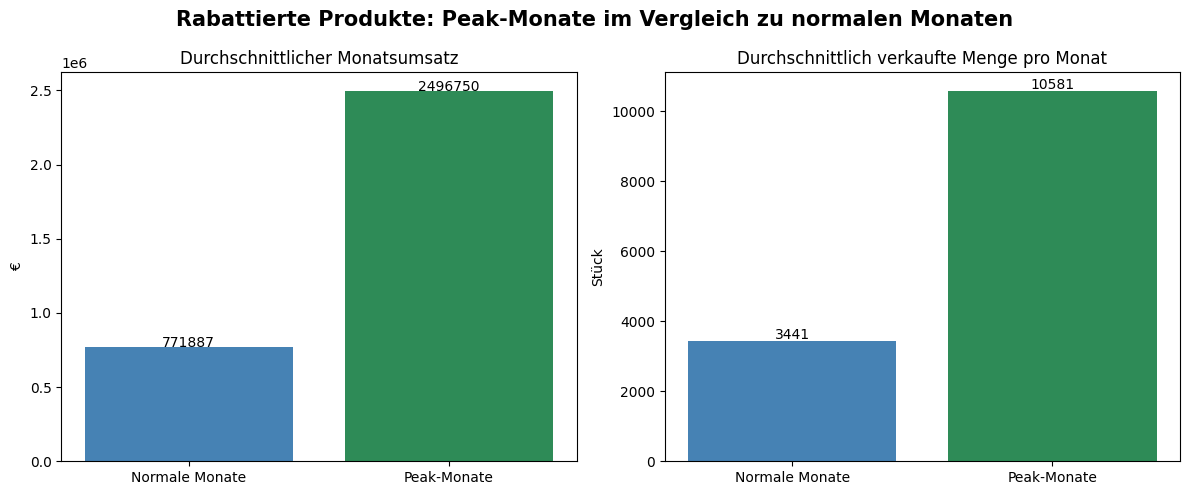

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average Monthly Revenue
axes[0].bar(
    q2_performance["saison"],
    q2_performance["durchschnittlicher_monatsumsatz"],
    color=["steelblue", "seagreen"]
)
axes[0].set_title("Durchschnittlicher Monatsumsatz")
axes[0].set_ylabel("€")

for i, v in enumerate(q2_performance["durchschnittlicher_monatsumsatz"]):
    axes[0].text(i, v + 1000, f"{v:.0f}", ha="center")

# Average Monthly Quantity Sold
axes[1].bar(
    q2_performance["saison"],
    q2_performance["durchschnittliche_monatsverkaufsmenge"],
    color=["steelblue", "seagreen"]
)
axes[1].set_title("Durchschnittlich verkaufte Menge pro Monat")
axes[1].set_ylabel("Stück")

for i, v in enumerate(q2_performance["durchschnittliche_monatsverkaufsmenge"]):
    axes[1].text(i, v + 50, f"{v:.0f}", ha="center")

plt.suptitle("Rabattierte Produkte: Peak-Monate im Vergleich zu normalen Monaten", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Ergebnis:**
* Die Analyse zeigt, dass rabattierte Produkte in den Peak-Monaten deutlich höhere durchschnittliche Monatsumsätze und Verkaufsmengen erzielen als in den Normalmonaten. Dies deutet darauf hin, dass rabattierte Produkte insbesondere während der Peak-Saison deutlich stärker nachgefragt werden.

8.7.Vergleich von Monatsumsatz und Verkaufsmenge nach Rabattstufe in Peak- und Normalmonaten

,saison,discount_level,durchschnittlicher_monatsumsatz,durchschnittliche_monatsverkaufsmenge
0,Normal,Niedrig,396010.19,906.89
1,Normal,Mittel,314474.54,1667.33
2,Normal,Hoch,61402.48,866.44
3,Peak,Niedrig,1158936.71,2425.00
4,Peak,Mittel,1130773.59,5503.00
5,Peak,Hoch,207039.38,2653.33


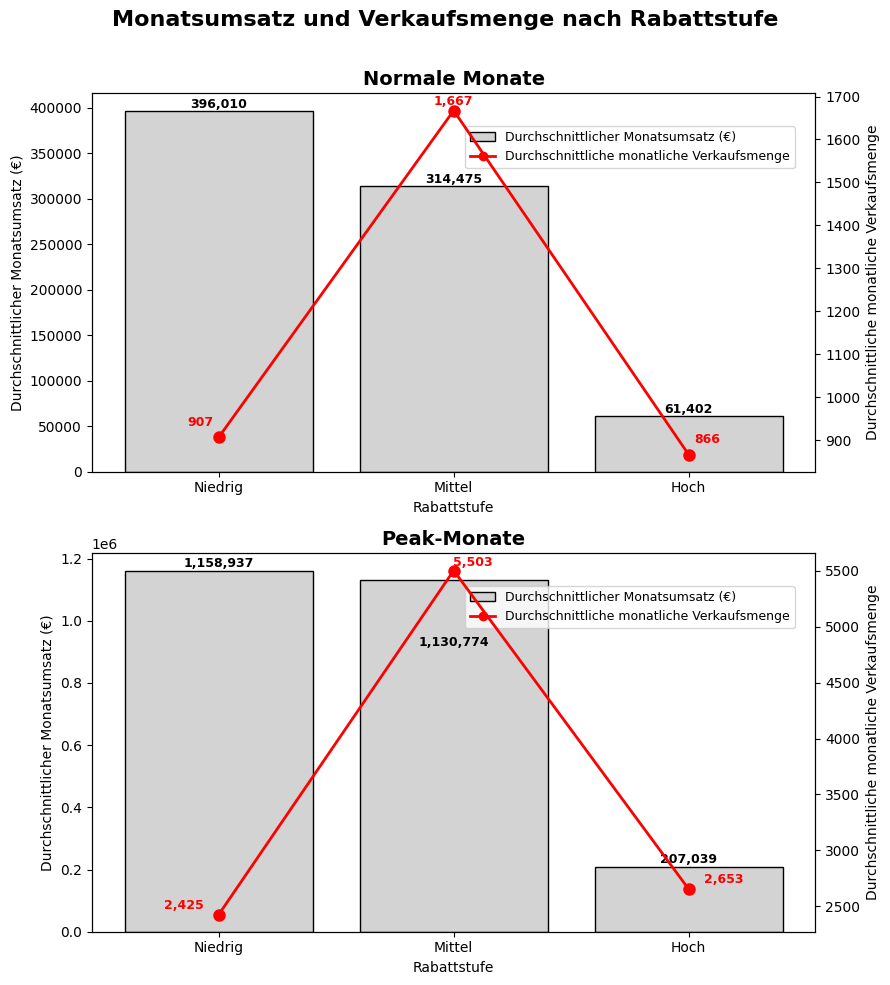

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ============================================================
# Daten vorbereiten
# ============================================================

q3 = m.copy()
# ============================================================
# Monatsnamen aus der Datumsspalte erstellen
# ============================================================

q3["date"] = pd.to_datetime(
    q3["date"],
    errors="coerce"
)

monatsnamen = {
    1: "Jan",
    2: "Feb",
    3: "Mär",
    4: "Apr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Okt",
    11: "Nov",
    12: "Dez"
}

q3["monat_name"] = (
    q3["date"]
    .dt.month
    .map(monatsnamen)
)

# Peak-Monate definieren
peak_monate = ["Nov", "Dez", "Jan"]

# Saison erstellen
q3["saison"] = q3["monat_name"].apply(
    lambda x: "Peak" if x in peak_monate else "Normal"
)

# Nur gültige Rabatte verwenden
q3 = q3[
    (q3["discount_percent"] > 0)
    & (q3["discount_percent"] <= 100)
].copy()

# ============================================================
# Rabattstufen anhand der Quartile berechnen
# ============================================================

q1 = q3["discount_percent"].quantile(0.25)
q3_quartile = q3["discount_percent"].quantile(0.75)

q3["discount_level"] = pd.cut(
    q3["discount_percent"],
    bins=[0, q1, q3_quartile, 100],
    labels=["Niedrig", "Mittel", "Hoch"],
    include_lowest=True
)

# ============================================================
# Monatswerte berechnen
# ============================================================

monthly_performance = (
    q3.groupby(
        ["saison", "discount_level", "monat_name"],
        observed=True
    )
    .agg(
        monatsumsatz=("umsatz", "sum"),
        monatsverkaufsmenge=("product_quantity", "sum")
    )
    .reset_index()
)

# ============================================================
# Durchschnittswerte je Saison und Rabattstufe
# ============================================================

q3_performance = (
    monthly_performance.groupby(
        ["saison", "discount_level"],
        observed=True
    )
    .agg(
        durchschnittlicher_monatsumsatz=("monatsumsatz", "mean"),
        durchschnittliche_monatsverkaufsmenge=("monatsverkaufsmenge", "mean")
    )
    .reset_index()
)

q3_performance = q3_performance.round(2)

display(q3_performance)

# ============================================================
# Daten für beide Diagramme trennen
# ============================================================

normal = q3_performance[
    q3_performance["saison"] == "Normal"
]

peak = q3_performance[
    q3_performance["saison"] == "Peak"
]

# ============================================================
# Abbildung erstellen
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 10)
)

# ============================================================
# Legende definieren
# ============================================================

legend_elements = [
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Durchschnittlicher Monatsumsatz (€)"
    ),
    Line2D(
        [0],
        [0],
        color="red",
        marker="o",
        linewidth=2,
        label="Durchschnittliche monatliche Verkaufsmenge"
    )
]
# ============================================================
# Diagramm 1: Normale Monate
# ============================================================

ax1 = axes[0]
ax2 = ax1.twinx()

# Balkendiagramm erstellen
bars = ax1.bar(
    normal["discount_level"],
    normal["durchschnittlicher_monatsumsatz"],
    color="lightgray",
    edgecolor="black"
)

# Liniendiagramm erstellen
ax2.plot(
    normal["discount_level"],
    normal["durchschnittliche_monatsverkaufsmenge"],
    color="red",
    marker="o",
    linewidth=2,
    markersize=8
)

# Titel und Achsenbeschriftungen
ax1.set_title(
    "Normale Monate",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Rabattstufe")
ax1.set_ylabel("Durchschnittlicher Monatsumsatz (€)")
ax2.set_ylabel("Durchschnittliche monatliche Verkaufsmenge")

# Werte über den Balken anzeigen
for bar in bars:

    hoehe = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        hoehe,
        f"{hoehe:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Werte über den roten Punkten anzeigen
# Werte der roten Linie anzeigen

for i, (x, y) in enumerate(
    zip(
        normal["discount_level"],
        normal["durchschnittliche_monatsverkaufsmenge"]
    )
):

    x_pos = x
    y_pos = y + 20

    # Linker Punkt
    if i == 0:
        x_pos = -0.08

    # Mittlerer Punkt
    elif i == 1:
        x_pos = 1.00
        y_pos = y+5
    # Rechter Punkt
    elif i == 2:
        x_pos = 2.08

    ax2.text(
        x_pos,
        y_pos,
        f"{y:,.0f}",
        color="red",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Legende rechts platzieren
ax1.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.93),
    fontsize=9,
    frameon=True
)
# ============================================================
# Diagramm 2: Peak-Monate
# ============================================================

ax3 = axes[1]
ax4 = ax3.twinx()

# Balkendiagramm erstellen
bars = ax3.bar(
    peak["discount_level"],
    peak["durchschnittlicher_monatsumsatz"],
    color="lightgray",
    edgecolor="black"
)

# Liniendiagramm erstellen
ax4.plot(
    peak["discount_level"],
    peak["durchschnittliche_monatsverkaufsmenge"],
    color="red",
    marker="o",
    linewidth=2,
    markersize=8
)

# ------------------------------------------------------------
# Titel und Achsenbeschriftungen
# ------------------------------------------------------------

ax3.set_title(
    "Peak-Monate",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Rabattstufe")
ax3.set_ylabel("Durchschnittlicher Monatsumsatz (€)")
ax4.set_ylabel("Durchschnittliche monatliche Verkaufsmenge")

# ------------------------------------------------------------
# Umsatzwerte auf den Balken anzeigen
# ------------------------------------------------------------

for i, bar in enumerate(bars):

    hoehe = bar.get_height()

    x = bar.get_x() + bar.get_width()/2

    # Standardposition
    y = hoehe + 25000

    # Mittleren Balken in den Balken verschieben
    if i == 1:
        y = hoehe - 200000

    ax3.text(
        x,
        y,
        f"{hoehe:,.0f}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Werte der roten Linie anzeigen
# ------------------------------------------------------------

# Werte der roten Linie anzeigen

for i, (x, y) in enumerate(
    zip(
        peak["discount_level"],
        peak["durchschnittliche_monatsverkaufsmenge"]
    )
):

    x_pos = x
    y_pos = y + 25

    # Linker Punkt
    if i == 0:
        x_pos = -0.15

    # Mittlerer Punkt
    elif i == 1:
        x_pos = 1.08
        y_pos = y + 10

    # Rechter Punkt
    elif i == 2:
        x_pos = 2.15

    ax4.text(
        x_pos,
        y_pos,
        f"{y:,.0f}",
        color="red",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )
# ------------------------------------------------------------
# Legende rechts oben platzieren
# ------------------------------------------------------------

ax3.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.93),
    fontsize=9,
    frameon=True
)

# ------------------------------------------------------------
# Gesamttitel und Layout
# ------------------------------------------------------------

plt.suptitle(
    "Monatsumsatz und Verkaufsmenge nach Rabattstufe",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

**Ergebnis:**

* Die Analyse zeigt, dass sowohl in den Normal- als auch in den Peak-Monaten die mittlere Rabattstufe (Mittel) die höchste durchschnittliche monatliche Verkaufsmenge erzielt. Der durchschnittliche Monatsumsatz liegt bei niedrigen und mittleren Rabatten auf einem ähnlich hohen Niveau und ist deutlich höher als bei hohen Rabatten. Hohe Rabatte führen weder in den Normal- noch in den Peak-Monaten automatisch zu höheren Umsätzen oder Verkaufsmengen.

8.8.Umsatz- und Verkaufsmengenvergleich zwischen Produkten ohne Rabatt und mit niedrigem Rabatt in den Peak-Monaten

In [ ]:
q4 = m.copy()

# ============================================================
# Kopie des Analysedatensatzes erstellen
# ============================================================


# ============================================================
# Datumsformat umwandeln und Monatsnamen erzeugen
# ============================================================

q4["date"] = pd.to_datetime(
    q4["date"],
    errors="coerce"
)

monatsnamen = {
    1: "Jan",
    2: "Feb",
    3: "Mär",
    4: "Apr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Okt",
    11: "Nov",
    12: "Dez"
}

q4["monat_name"] = (
    q4["date"]
    .dt.month
    .map(monatsnamen)
)

# ============================================================
# Peak-Monate definieren und Datensatz filtern
# ============================================================

peak_monate = ["Nov", "Dez", "Jan"]

q4["saison"] = q4["monat_name"].apply(
    lambda x: "Peak" if x in peak_monate else "Normal"
)

q4 = q4[q4["saison"] == "Peak"]

# ============================================================
# Nur gültige Rabattwerte (0 % bis 100 %) berücksichtigen
# ============================================================

q4 = q4[
    (q4["discount_percent"] >= 0)
    & (q4["discount_percent"] <= 100)
]

# ============================================================
# Quartilsgrenze (Q1) für niedrige Rabatte berechnen
# ============================================================

q1 = q4.loc[
    q4["discount_percent"] > 0,
    "discount_percent"
].quantile(0.25)

# ============================================================
# Rabattgruppen erstellen
# ============================================================

q4["discount_group"] = q4["discount_percent"].apply(
    lambda x:
        "Kein Rabatt" if x == 0
        else "Niedriger Rabatt" if 0 < x <= q1
        else None
)

# ============================================================
# Nur die benötigten Rabattgruppen auswählen
# ============================================================

q4 = q4[q4["discount_group"].notna()]

# ============================================================
# Monatliche Kennzahlen berechnen
# ============================================================

monthly = (
    q4.groupby(
        ["discount_group", "monat_name"],
        observed=True
    )
    .agg(
        monatsumsatz=("umsatz", "sum"),
        monatsverkaufsmenge=("product_quantity", "sum")
    )
    .reset_index()
)

# ============================================================
# Durchschnittliche Monatswerte je Rabattgruppe berechnen
# ============================================================

q4_performance = (
    monthly.groupby(
        "discount_group",
        observed=True
    )
    .agg(
        durchschnittlicher_monatsumsatz=("monatsumsatz", "mean"),
        durchschnittliche_monatsverkaufsmenge=("monatsverkaufsmenge", "mean")
    )
    .reset_index()
)

q4_performance = q4_performance.round(2)

display(q4_performance)

,discount_group,durchschnittlicher_monatsumsatz,durchschnittliche_monatsverkaufsmenge
0,Kein Rabatt,52790.39,364.67
1,Niedriger Rabatt,1259928.23,2603.33


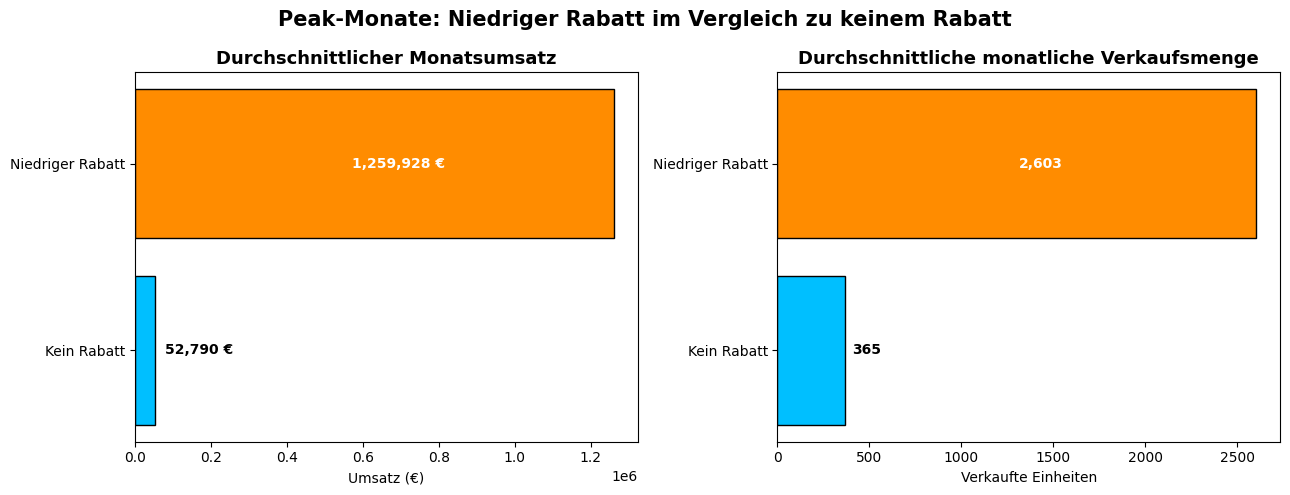

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# Abbildung mit zwei Diagrammen erstellen
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# ============================================================
# Farben für die Rabattgruppen festlegen
# Kein Rabatt = Orange
# Niedriger Rabatt = Blau
# ============================================================

colors = ["deepskyblue", "darkorange"]

# ============================================================
# Diagramm 1: Durchschnittlicher Monatsumsatz
# ============================================================

bars1 = axes[0].barh(
    q4_performance["discount_group"],
    q4_performance["durchschnittlicher_monatsumsatz"],
    color=colors,
    edgecolor="black"
)

axes[0].set_title(
    "Durchschnittlicher Monatsumsatz",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Umsatz (€)")

# Umsatzwerte auf den Balken anzeigen

for bar in bars1:

    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2

    if width > 200000:

        axes[0].text(
            width * 0.55,
            y,
            f"{width:,.0f} €",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    else:

        axes[0].text(
            width + 25000,
            y,
            f"{width:,.0f} €",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

# ============================================================
# Diagramm 2: Durchschnittliche monatliche Verkaufsmenge
# ============================================================

bars2 = axes[1].barh(
    q4_performance["discount_group"],
    q4_performance["durchschnittliche_monatsverkaufsmenge"],
    color=colors,
    edgecolor="black"
)

axes[1].set_title(
    "Durchschnittliche monatliche Verkaufsmenge",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Verkaufte Einheiten")

# Verkaufsmengen auf den Balken anzeigen

for bar in bars2:

    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2

    if width > 800:

        axes[1].text(
            width * 0.55,
            y,
            f"{width:,.0f}",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    else:

        axes[1].text(
            width + 40,
            y,
            f"{width:,.0f}",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

# ============================================================
# Gesamttitel und Layout
# ============================================================

plt.suptitle(
    "Peak-Monate: Niedriger Rabatt im Vergleich zu keinem Rabatt",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

**Ergebnis:**

* Die Analysen zeigen einen deutlichen saisonalen Einfluss auf Umsatz und Verkaufsmenge. Während der Peak-Monate werden die höchsten Umsätze und Verkaufszahlen erzielt.
* Rabattierte Produkte erzielen in Peak-Monaten deutlich höhere Umsätze und Verkaufsmengen als in normalen Monaten.
* Ein mittleres Rabattniveau führt sowohl in normalen als auch in Peak-Monaten zur höchsten durchschnittlichen Verkaufsmenge, während hohe Rabatte die schlechtesten Ergebnisse liefern.
* Bereits geringe Rabatte erzielen im Vergleich zu keinem Rabatt deutlich höhere Umsätze und Verkaufszahlen.

**Vermutung:**

* Die hohe Nachfrage in den Peak-Monaten verstärkt die Wirkung von Rabattaktionen und trägt wesentlich zum Umsatzwachstum bei.
* Moderate Rabatte scheinen für Kunden attraktiver zu sein als sehr hohe Rabatte, ohne den Umsatz unnötig zu reduzieren.
* Saisonale Nachfrage und Rabattstrategie beeinflussen den Verkauf gemeinsam und nicht unabhängig voneinander.

**Pro Marketing:**

* Rabattaktionen sollten gezielt auf Peak-Monate ausgerichtet werden, da dort der größte Verkaufseffekt erzielt wird.
* Moderate Rabatte bieten das beste Verhältnis zwischen Umsatz und Verkaufsmenge.
* Bereits kleine Preisnachlässe können einen deutlichen positiven Einfluss auf den Verkauf haben.

**Contra Vorstand:**

* Höhere Rabatte führen nicht automatisch zu höheren Umsätzen oder höheren Verkaufszahlen.
* Die Ergebnisse zeigen nur den Zusammenhang mit Umsatz und Verkaufsmenge; Aussagen über die tatsächliche Rentabilität sind ohne Informationen zu Einkaufspreisen und Gewinnmargen nicht möglich.
* Saisonale Nachfrage kann die Ergebnisse beeinflussen, sodass Rabatte nicht als alleiniger Erfolgsfaktor betrachtet werden sollten.

**Fazit:**

* Die Ergebnisse zeigen, dass die Kombination aus saisonaler Nachfrage und einer gezielten Rabattstrategie den größten Einfluss auf den Verkaufserfolg hat. Moderate Rabatte erzielen die besten Ergebnisse, während hohe Rabatte keinen zusätzlichen Nutzen bringen. Daher empfiehlt sich eine saison- und produktabhängige Rabattstrategie anstelle pauschaler hoher Preisnachlässe.

In [ ]:
##Zusatzanalyse: Wochentags- und Monatsanalyse

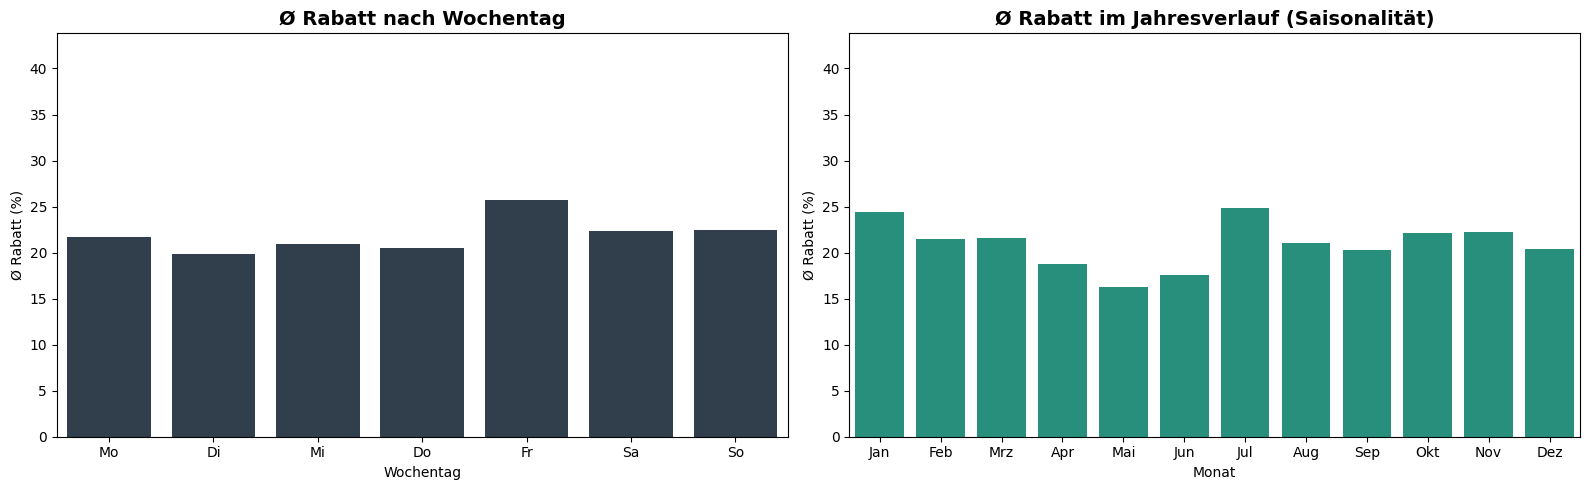

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Datetime sicherstellen und Zeitkomponenten extrahieren
m['created_date'] = pd.to_datetime(m['created_date'])

# Wochentage extrahieren (0=Montag, 6=Sonntag) und lesbar benennen
wochentage_namen = {0: 'Mo', 1: 'Di', 2: 'Mi', 3: 'Do', 4: 'Fr', 5: 'Sa', 6: 'So'}
m['wochentag'] = m['created_date'].dt.weekday.map(wochentage_namen)
wochentag_reihenfolge = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

# Reine Monatsnummer für die saisonale Übersicht extrahieren (1 bis 12)
m['monat_num'] = m['created_date'].dt.month
monat_namen = {1: 'Jan', 2: 'Feb', 3: 'Mrz', 4: 'Apr', 5: 'Mai', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Dez'}
m['monat_name'] = m['monat_num'].map(monat_namen)
monat_reihenfolge = ['Jan', 'Feb', 'Mrz', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']

# 2. Aggregieren: Durchschnittlicher Rabatt je Wochentag und je Monat
rabatt_wochentag = m.groupby('wochentag', as_index=False)['discount_percent'].mean()
rabatt_monat = m.groupby('monat_name', as_index=False)['discount_percent'].mean()

# 3. Diagramme vorbereiten (2 Grafiken nebeneinander)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- LINKES DIAGRAMM: WOCHENTAGE ---
sns.barplot(
    data=rabatt_wochentag,
    x='wochentag',
    y='discount_percent',
    order=wochentag_reihenfolge,
    ax=axes[0],
    color='#2c3e50'
)
axes[0].set_title('Ø Rabatt nach Wochentag', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Wochentag')
axes[0].set_ylabel('Ø Rabatt (%)')
axes[0].set_ylim(0, m['discount_percent'].mean() * 2) # Dynamische Skalierung

# --- RECHTES DIAGRAMM: MONATE (SAISONALITÄT) ---
sns.barplot(
    data=rabatt_monat,
    x='monat_name',
    y='discount_percent',
    order=monat_reihenfolge,
    ax=axes[1],
    color='#16a085'
)
axes[1].set_title('Ø Rabatt im Jahresverlauf (Saisonalität)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monat')
axes[1].set_ylabel('Ø Rabatt (%)')
axes[1].set_ylim(0, m['discount_percent'].mean() * 2)

plt.tight_layout()
plt.show()

**Ergebnis:**

Eniac betreibt ein Dauerrabatt-Modell (High-Low-Pricing im Dauermodus)

###8.9.Die exakte Tagesanalyse

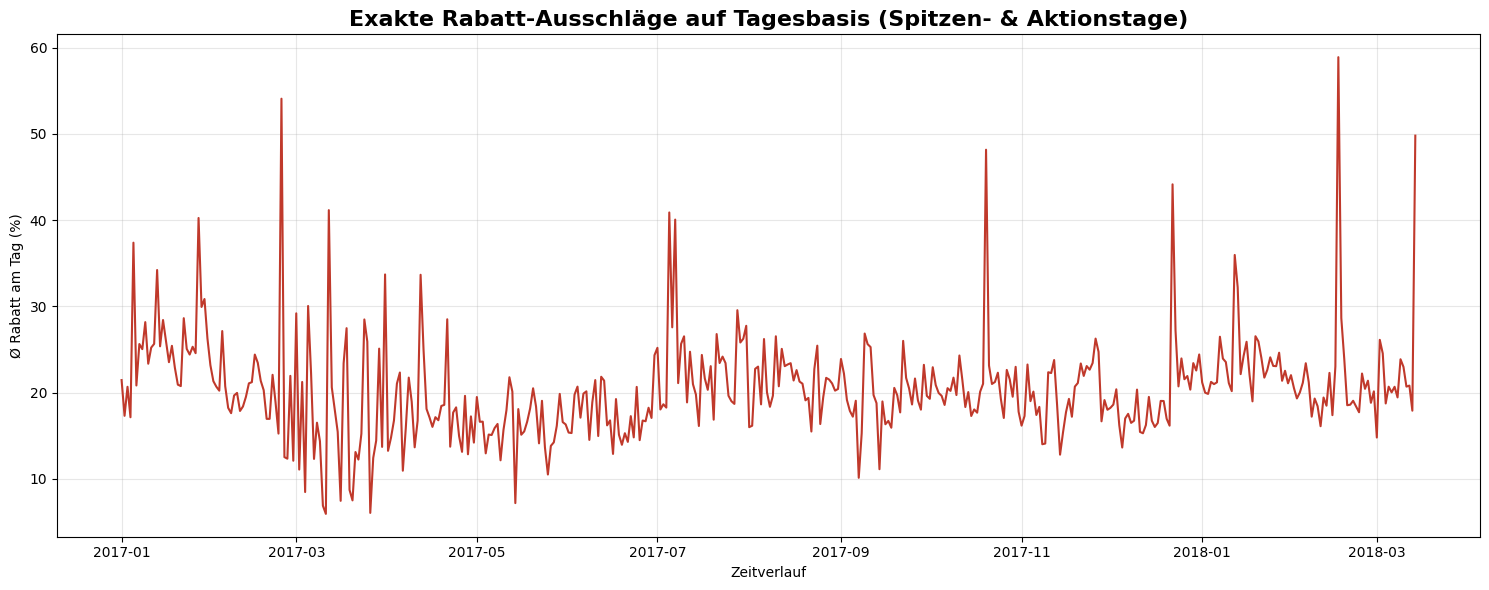

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten nach dem exakten Kalendertag gruppieren (z. B. 2023-11-24)
m['exact_date'] = m['created_date'].dt.date
tages_trend = m.groupby('exact_date', as_index=False)['discount_percent'].mean()

# 2. Das Diagramm zeichnen
fig, ax = plt.subplots(figsize=(15, 6))

# Lineplot zeigt die harten Ausschläge über die Zeit
sns.lineplot(data=tages_trend, x='exact_date', y='discount_percent', color='#c0392b', linewidth=1.5, ax=ax)

# Titel und Achsen vorstandstauglich beschriften
ax.set_title('Exakte Rabatt-Ausschläge auf Tagesbasis (Spitzen- & Aktionstage)', fontsize=16, fontweight='bold')
ax.set_xlabel('Zeitverlauf')
ax.set_ylabel('Ø Rabatt am Tag (%)')
ax.grid(True, alpha=0.3) # Gitterlinien helfen beim Ablesen der Daten

plt.tight_layout()
plt.show()

Ergebnis:

**Fazit:**

Pro Vorstand
- Die Nadeln ggf an bekannten Aktionstagen (Black Friday Ende November) extrem in die Höhe (z. B. auf 40 % oder 50 %).
=> aggressive Preispolitik. Marketing macht ein Rabattfeuerwerk an einzelnen Tagen.
=> Dies zieht den Umsatz aus den normalen Wochen ab und schaden der Premium-Marke.

Pro Marketing
- Diese Spitzen könnten gezielte, kurzfristige Interventionen sein!
Beispiel: Das Lager bei bestimmten Apple-Zubehörteilen ist zu voll oder wenn ein Quartalsziel knapp wird, nutzen wir 24-Stunden-Blitzrabatte, um sofort Liquidität und Aufträge zu generieren. Das wäre effizientes, datengetriebenes Bestandsmanagement.“

###8.10.Zusatzanalyse: TOP 5 RABATT-TAGE

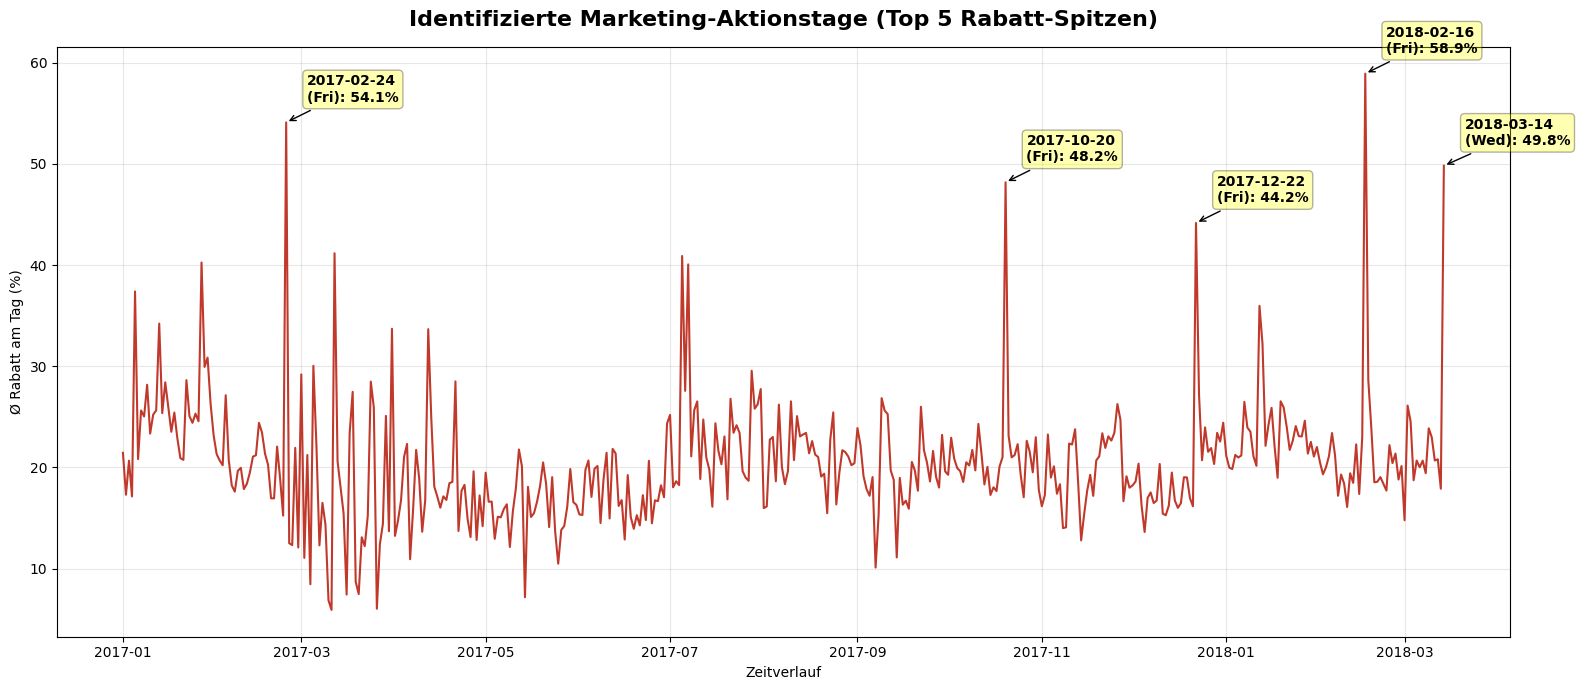


--- TOP 5 RABATT-TAGE (TABELLE FÜR PRÄSENTATION) ---
     Datum Wochentag  Ø Rabatt (%)
2018-02-16    Friday         58.91
2017-02-24    Friday         54.10
2018-03-14 Wednesday         49.81
2017-10-20    Friday         48.18
2017-12-22    Friday         44.16


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten aggregieren auf Tagesbasis
m['exact_date'] = pd.to_datetime(m['created_date']).dt.date
tages_trend = m.groupby('exact_date', as_index=False)['discount_percent'].mean()

# 2. Die Top 5 Tage mit den absolut höchsten durchschnittlichen Rabatten finden
# (Diese nutzen wir für die automatische Beschriftung im Diagramm)
top_spitzen = tages_trend.sort_values('discount_percent', ascending=False).head(5)

# 3. Diagramm zeichnen
fig, ax = plt.subplots(figsize=(16, 7))
sns.lineplot(data=tages_trend, x='exact_date', y='discount_percent', color='#c0392b', linewidth=1.5, ax=ax)

# 4. AUTOMATISCHE TEXT-ANNOTATION FÜR DIE SPITZEN
for idx, row in top_spitzen.iterrows():
    datum = row['exact_date']
    rabatt_wert = row['discount_percent']

    # Wochentag für den Kontext ermitteln
    wochentag = pd.to_datetime(datum).strftime('%a') # Gibt Mo, Di, etc.
    text = f"{datum}\n({wochentag}): {rabatt_wert:.1f}%"

    # Text-Pfeile im Diagramm platzieren
    ax.annotate(
        text,
        xy=(datum, rabatt_wert),
        xytext=(15, 15),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3)
    )

# Titel und Achsen vorstandstauglich beschriften
ax.set_title('Identifizierte Marketing-Aktionstage (Top 5 Rabatt-Spitzen)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Zeitverlauf')
ax.set_ylabel('Ø Rabatt am Tag (%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- ZUSÄTZLICHE TABELLE FÜR DEN VORSTANDSBERICHT ---
print("\n--- TOP 5 RABATT-TAGE (TABELLE FÜR PRÄSENTATION) ---")
top_spitzen_anzeige = top_spitzen.copy()
top_spitzen_anzeige['Wochentag'] = pd.to_datetime(top_spitzen_anzeige['exact_date']).dt.strftime('%A')
top_spitzen_anzeige = top_spitzen_anzeige.rename(columns={'exact_date': 'Datum', 'discount_percent': 'Ø Rabatt (%)'})
print(top_spitzen_anzeige[['Datum', 'Wochentag', 'Ø Rabatt (%)']].to_string(index=False))

Ergebnis:

**Fazit:**

Pro Vorstand
- November 2017: Da ist der offizielle Black Friday. Es gibt dort keinen einzigen großen Rabatt-Ausschlag.
- Rabatt-Schlachten (54 % und 59 %) finden stattdessen Ende Februar 2017 und Mitte Februar 2018 statt.

=> Hier wurde anscheinend das wichtigste globalen Shopping-Events des Jahres (Black Friday) verpasst. Dafür wurde aber mitten im Februar – ohne jeden saisonalen Anlass – unkontrollierte Rabatte von fast 60 % in den Markt gegeben. Das zerstört die Marge in Monaten, in denen Apple-Kunden eigentlich normale Preise zahlen würden.“

Pro Marketing
- 5 Spitzen-Tage exakt an einem Freitag *(kein Muster/Auszug)*
=> ggf gezielte Aktionen z.B. das 'Wochenend-Shopping', um Kunden pünktlich zum Gehaltseingang am Freitag mit Flash-Sales (Blitzrabatten) in den Shop zu ziehen. Der Peak am 22.12.2017 (Freitag vor Heiligabend) beweist, dass das Last-Minute-Weihnachtsgeschäft perfekt abgegriffen wurde.

###8.11.Zusatzanalyse: Einzelne Spitzentage

In [ ]:
# 1. Die exakten Datums-Werte der Top-5-Spitzen als Liste extrahieren
spitzen_daten = top_spitzen['exact_date'].tolist()

# 2. Die Originaldaten 'm' auf genau diese 5 Tage filtern
m['exact_date_dt'] = pd.to_datetime(m['created_date']).dt.date
spitzen_details = m[m['exact_date_dt'].isin(spitzen_daten)]

# 3. Auswertung: Welche Kategorien wurden an diesen Tagen wie stark rabattiert?
spitzen_analyse = spitzen_details.groupby(['exact_date_dt', 'category']).agg(
    anzahl_verkauf_positionen=('id_order', 'count'),
    gesamt_umsatz_am_tag=('umsatz', 'sum'),
    durchschnitts_rabatt_am_tag=('discount_percent', 'mean')
).reset_index().sort_values(['exact_date_dt', 'gesamt_umsatz_am_tag'], ascending=[True, False])

# 4. Schöne Ausgabe für den Vorstand
print("--- PRODUKT-ANALYSE AN DEN TOP 5 MARKETING-AKTIONSTAGEN ---")
print(spitzen_analyse.to_string(index=False))

--- PRODUKT-ANALYSE AN DEN TOP 5 MARKETING-AKTIONSTAGEN ---
exact_date_dt             category  anzahl_verkauf_positionen  gesamt_umsatz_am_tag  durchschnitts_rabatt_am_tag
   2017-02-24        Mobile Phones                          2                 99.98                        54.10
   2017-10-20     Computers (iMac)                          5               9034.75                        17.13
   2017-10-20        Storage & NAS                         24               8043.64                        11.44
   2017-10-20              Tablets                        136               6660.49                        69.29
   2017-10-20  Computers (MacBook)                          6               5451.04                        39.63
   2017-10-20 Components (RAM/SSD)                         21               2542.88                        21.65
   2017-10-20        Mobile Phones                         19               2118.09                        23.22
   2017-10-20             Monitors  

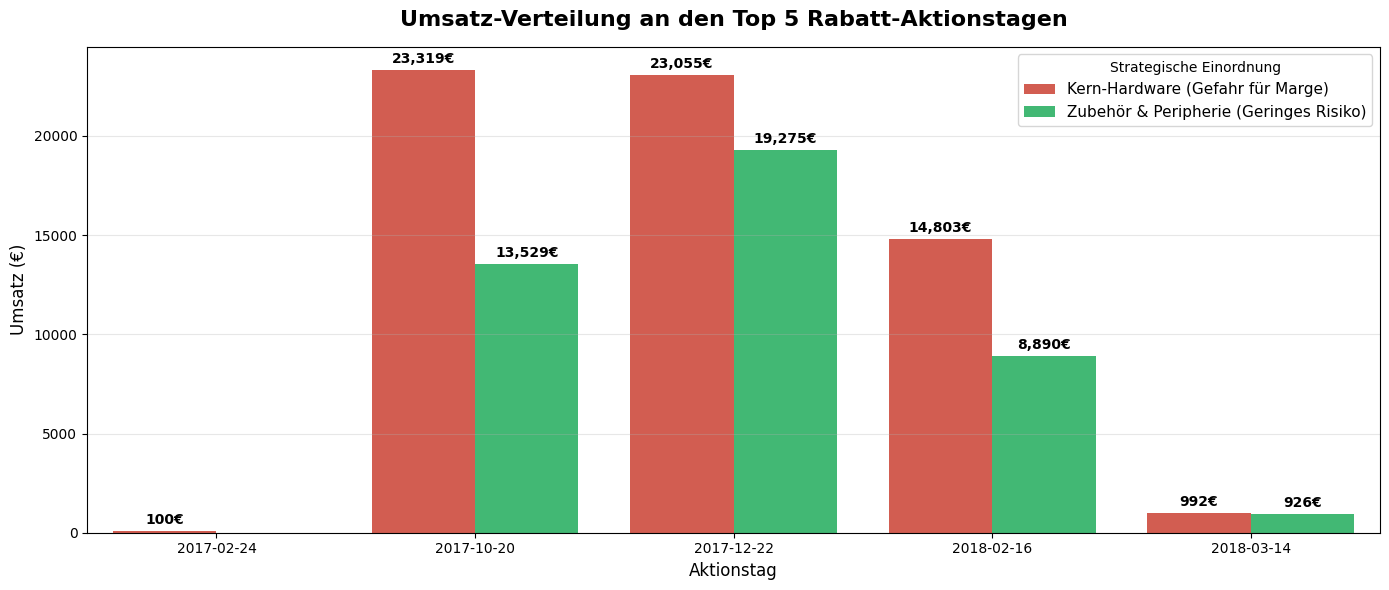

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kategorien in zwei strategische Gruppen aufteilen
def gruppiere_kategorie(cat):
    hardware = ['Computers (MacBook)', 'Computers (iMac)', 'Computers (Mac Mini)', 'Mobile Phones', 'Tablets']
    if cat in hardware:
        return 'Kern-Hardware (Gefahr für Marge)'
    else:
        return 'Zubehör & Peripherie (Geringes Risiko)'

# Neue Spalte für die Gruppe anlegen
spitzen_details = spitzen_details.copy()
spitzen_details['Kategorie-Typ'] = spitzen_details['category'].apply(gruppiere_kategorie)

# 2. Daten aggregieren nach Tag und Kategorie-Typ
grafik_data = spitzen_details.groupby(['exact_date_dt', 'Kategorie-Typ']).agg(
    umsatz=('umsatz', 'sum'),
    rabatt=('discount_percent', 'mean')
).reset_index()

# Datum als Text für die X-Achse
grafik_data['Datum'] = grafik_data['exact_date_dt'].astype(str)

# 3. Diagramm zeichnen: Umsatz als Balken, Rabatt als Text darüber
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=grafik_data,
    x='Datum',
    y='umsatz',
    hue='Kategorie-Typ',
    palette=['#e74c3c', '#2ecc71'], # Rot für Hardware, Grün für Zubehör
    ax=ax
)

# Umsatz- und Rabattwerte direkt auf die Balken schreiben für maximale Lesbarkeit
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Finde den passenden Rabattwert für diesen Balken
        ax.annotate(
            f"{height:,.0f}€",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center', xytext=(0, 8),
            textcoords='offset points', fontsize=10, fontweight='bold'
        )

# Design anpassen
ax.set_title('Umsatz-Verteilung an den Top 5 Rabatt-Aktionstagen', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Aktionstag', fontsize=12)
ax.set_ylabel('Umsatz (€)', fontsize=12)
ax.legend(title='Strategische Einordnung', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Ergebnis:**

CONTRA-Rabatt-Entscheidung:
- Der 20.10.2017 zeig eindeutig (Roter Balken explodiert):An diesem Tag macht die Kern-Hardware einen riesigen Umsatz (über 21.000 €). Siehe Tabelle: An diesem Tag werden MacBooks mit 40 % und iPads mit 69 % Rabatt "verschleudert"

**Fazit: **
Beweis für den Vorstand. Das Marketing nutzt Rabatte nicht als kleinen Anreiz, sondern verbrennt massiv Marge bei den teuersten Apple-Produkten.

- Der 16.02.2018 ist das „Musterbeispiel“ (Grüner Balken zeigt Zubehör):
An diesem Tag wurde kaum Hardware verkauft, aber das Zubehör lief fantastisch (Accessories & Cables) mit einem Rabatt von 75,7 %. Da Zubehör riesige Gewinnspannen hat, war dieser Tag trotz des hohen Rabatts hochprofitabel.

**Finale Empfehlung für die künftige Strategie:**
Die Daten zeigen
=> ein klares Nein zu Hardware-Rabatten (Contra),
aber
=> ein Ja zu Zubehör-Rabatten (Pro).

**Empfehlung:**
Die Geschäftsleitung sollte
- dem Marketing verbieten, Apple-Kernprodukte zu reduzieren,
- darf ihnen aber freie Hand beim Abverkauf von Hüllen und Kabeln geben.

###8.12.Zusatzanalyse: Anteil rabattierter Produkte
Beantwortet die Meilenstein-5-Frage "Sind alle Produkte rabattiert?".

In [ ]:
anteil_rabattiert = (m['discount_percent'] > 0).mean() * 100
print(f"Anteil rabattierter Bestellpositionen: {anteil_rabattiert:.1f}%")

rabatt_nach_kategorie = m.groupby('category', as_index=False).agg(
    anteil_rabattiert=('discount_percent', lambda x: (x > 0).mean() * 100),
    mittlerer_rabatt=('discount_percent', 'mean')
).sort_values('anteil_rabattiert', ascending=False)
rabatt_nach_kategorie

Anteil rabattierter Bestellpositionen: 93.1%


,category,anteil_rabattiert,mittlerer_rabatt
1,Audio,96.79,26.54
12,Smart Home,95.36,25.15
14,Tablets,95.31,21.67
5,Computers (iMac),95.13,18.28
2,Components (RAM/SSD),95.07,19.54
13,Storage & NAS,94.99,16.40
4,Computers (MacBook),94.23,18.04
0,Accessories & Cables,93.81,26.32
10,Other,92.94,23.58
8,Monitors,90.53,11.86


Ergebnis:
- Finanzrealität: Zeigt wie viel Umsatz tatsächlich unter Rabatteinfluss stand.
- Der Vorstand sieht direkt, wie viel Marge durch Rabattaktionen im laufenden Quartal verloren geht.

##9.Zusatzanalysen aus den Seaborn-Übungsaufgaben (Herausforderung 3)

### 9.1.Option 1 — Preisempfehlung vs. tatsächlicher Verkaufspreis
Streudiagramm `products.price` vs. `orderlines.unit_price`; Punkte auf der Diagonale = kein Rabatt, Punkte darunter = rabattiert. Farbe zeigt die Rabatthöhe.

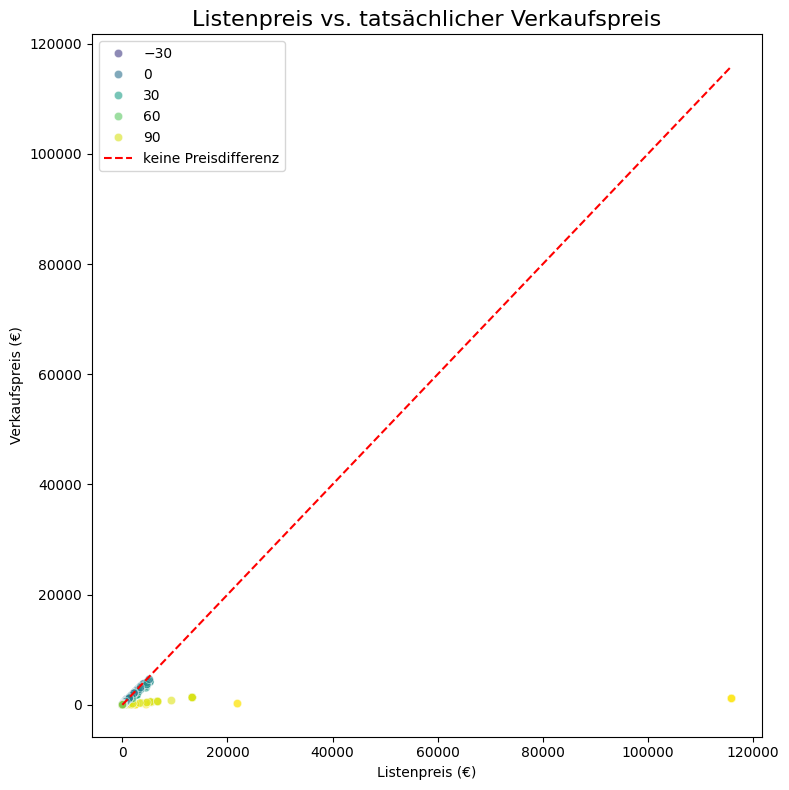

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = sns.scatterplot(
    data=m.sample(min(5000, len(m)), random_state=42),
    x='price', y='unit_price', hue='discount_percent',
    palette='viridis', alpha=0.6, ax=ax
)
max_val = m[['price', 'unit_price']].max().max()
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='keine Preisdifferenz')
ax.set_title('Listenpreis vs. tatsächlicher Verkaufspreis', fontsize=16)
ax.set_xlabel('Listenpreis (€)')
ax.set_ylabel('Verkaufspreis (€)')
ax.legend()
plt.tight_layout()
plt.show()

###9.2.Option 2 — Durchschnittlicher Bestellwert im Zeitverlauf
Zeigt, wann Kunden bereit sind, mehr auszugeben (monatliche Auflösung).

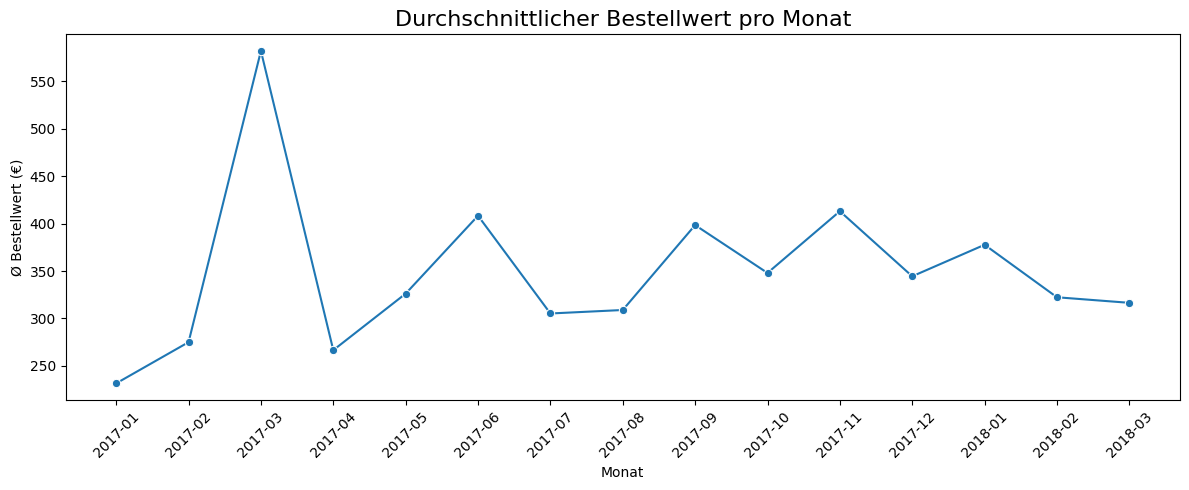

In [ ]:
avg_order_value = orders_analyse.groupby('month', as_index=False)['total_paid'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=avg_order_value, x=avg_order_value['month'].astype(str), y='total_paid', marker='o', ax=ax)
ax.set_title('Durchschnittlicher Bestellwert pro Monat', fontsize=16)
ax.set_xlabel('Monat')
ax.set_ylabel('Ø Bestellwert (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###9.3Option 3 — Top-10-Produkte Januar 2017 vs. Januar 2018
Zeigt, welche Produkte in beiden Jahren zu den Bestsellern zählten (Konstanz vs. Trendwechsel).

In [ ]:
jan2017 = orders_orderlines_products_analyse.loc[
    (orders_orderlines_products_analyse['created_date'].dt.year == 2017)
    & (orders_orderlines_products_analyse['created_date'].dt.month == 1)
]
jan2018 = orders_orderlines_products_analyse.loc[
    (orders_orderlines_products_analyse['created_date'].dt.year == 2018)
    & (orders_orderlines_products_analyse['created_date'].dt.month == 1)
]

top_jan2017 = jan2017.groupby('name', as_index=False)['product_quantity'].sum().nlargest(10, 'product_quantity')
top_jan2018 = jan2018.groupby('name', as_index=False)['product_quantity'].sum().nlargest(10, 'product_quantity')

gemeinsame_top_produkte = set(top_jan2017['name']) & set(top_jan2018['name'])
print('In beiden Jahren in den Top 10:', gemeinsame_top_produkte)

In beiden Jahren in den Top 10: {'IPhone AppleCare Protection Plan', 'Apple Lightning Cable Connector to USB 1m White (OEM)'}


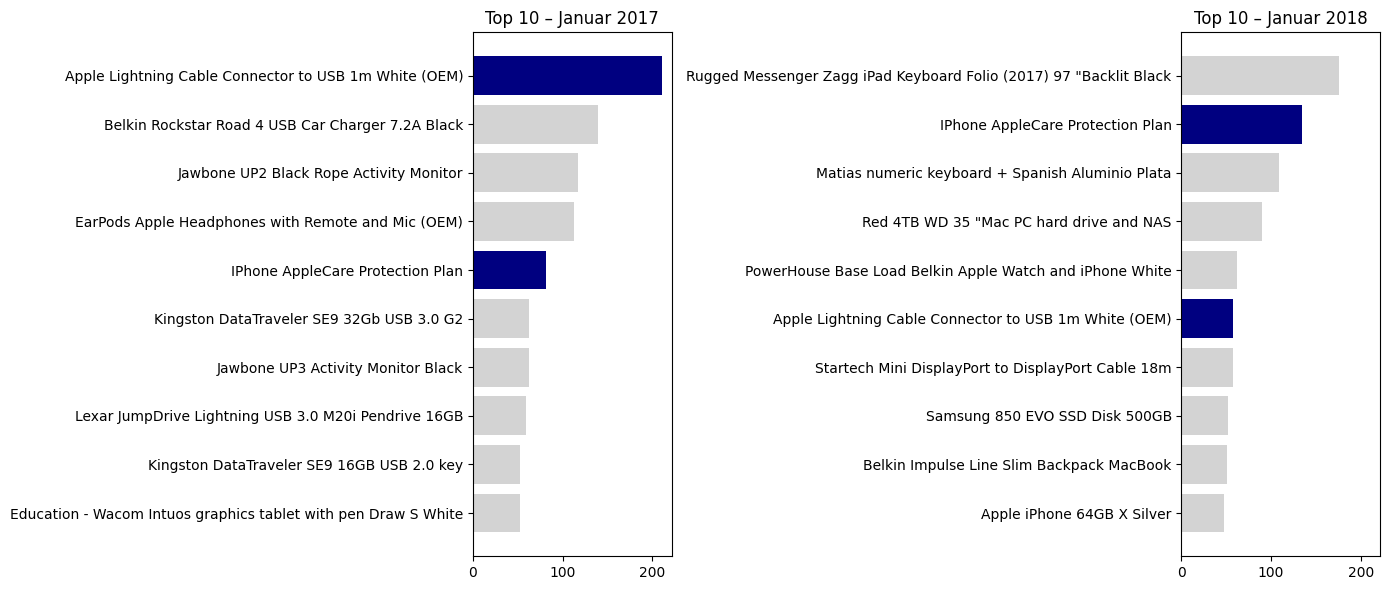

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

colors_2017 = ['navy' if n in gemeinsame_top_produkte else 'lightgray' for n in top_jan2017['name']]
colors_2018 = ['navy' if n in gemeinsame_top_produkte else 'lightgray' for n in top_jan2018['name']]

axes[0].barh(top_jan2017['name'], top_jan2017['product_quantity'], color=colors_2017)
axes[0].set_title('Top 10 – Januar 2017')
axes[0].invert_yaxis()

axes[1].barh(top_jan2018['name'], top_jan2018['product_quantity'], color=colors_2018)
axes[1].set_title('Top 10 – Januar 2018')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

##10.Zusammenfassung / Entscheidungsgrundlage für den CEO
**Nicht automatisch ausfüllen — Werte erst nach Ausführung der obigen Zellen eintragen (keine Zahlen erfinden).**

| Frage | Ergebnis | Pro-Rabatt-Interpretation | Contra-Rabatt-Interpretation |
|---|---|---|---|
| Umsatz steigt mit Rabatt? | *(aus Abschnitt 8 eintragen)* | | |
| Anteil rabattierter Produkte | *(aus Abschnitt 8 eintragen)* | | |
| Rabatt-Trend über Zeit | *(aus Abschnitt 8 eintragen)* | | |
| Kategorien mit stärkstem Rabatt | *(aus Abschnitt 8 eintragen)* | | |

**Empfehlung (Entwurf, im Team abstimmen):** ...

*Diese Tabelle bildet die Grundlage für die PowerPoint-Präsentation (Tag 12) — Diagramme aus diesem Notebook direkt als Bilder einbetten (siehe Projekt-Standard: Navy #1C2B6E / Ice-Blue #CADCFC).*

## 11. Speichern (Abschluss Analyse)
Export als `orders_analyse.csv`, `orderlines_analyse.csv`, `products_analyse.csv` — bewusst **andere Dateinamen** als in Meilenstein 4, damit die Qualitäts-Exporte nicht überschrieben werden.

In [ ]:
# from google.colab import files

# orders_analyse.to_csv("orders_analyse.csv", index=False)
# files.download("orders_analyse.csv")

# orderlines_analyse.to_csv("orderlines_analyse.csv", index=False)
# files.download("orderlines_analyse.csv")

# orderlines_products_analyse.to_csv("orderlines_products_merged_analyse.csv", index=False)
# files.download("orderlines_products_merged_analyse.csv")